# MathVisionP1 · Fase 2 · Análisis exploratorio exhaustivo

Este notebook desarrolla un análisis cuantitativo exhaustivo de `MathVisionP1.pdf` sobre `DatasetFull.csv`.
El objetivo es doble:

1. Analizar con detalle el rendimiento cuantitativo de los modelos.
2. Añadir análisis extra que ayuden a entender en qué condiciones fallan los modelos y cuándo fallan a la vez.

## Alcance y fuentes

Este cuaderno toma como referencia principal:

- Igualde-Sáez et al., *Evaluating Visual Mathematics in Multimodal LLMs: A Multilingual Benchmark Based on the Kangaroo Tests* (`arXiv:2506.07418`, 9 de junio de 2025).
- Rhomrasi et al., *LLM performance on mathematical reasoning in Catalan language* (*Results in Engineering*, volumen 25, marzo de 2025).

En el trabajo multimodal, la parte cuantitativa relevante para esta fase incluye:

- comparación global entre preguntas con y sin imagen,
- análisis por idioma y dificultad,
- coocurrencia de aciertos/fallos entre modelos,
- precisión por temática visual.

A partir de esas ideas, aquí añado:

- análisis de abstención (`No Answer`) y precisión condicionada a responder,
- peores subgrupos operativos por modelo,
- distribución de dureza por pregunta,
- estudio de fallos conjuntos,
- sesgos de respuesta por opción,
- comparación entre oráculos y voto mayoritario.

**Explicación celda**

Importa las librerías, fija el estilo gráfico y define las funciones auxiliares que se usarán en todo el cuaderno:
construcción del formato largo, radar por idioma y matrices de coocurrencia.

In [1]:
from __future__ import annotations

from collections import Counter
from itertools import combinations
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
pd.options.display.max_columns = 120
pd.options.display.max_colwidth = 140

DATA_PATH = Path("DatasetFull.csv")

MODEL_ORDER = [
    "Gemini 2.0 Flash",
    "Qwen-VL 72B",
    "GPT-4o",
    "Gemini 2.0 Flash Lite",
    "Qwen-VL 7B",
    "Pixtral Large",
    "Pixtral-12B",
    "Llama 3.2 90B Vision Instruct",
    "Llama 3.2 11B Vision Instruct",
]

MODEL_SHORT = {
    "Gemini 2.0 Flash": "Gemini Flash",
    "Qwen-VL 72B": "Qwen 72B",
    "GPT-4o": "GPT-4o",
    "Gemini 2.0 Flash Lite": "Gemini Lite",
    "Qwen-VL 7B": "Qwen 7B",
    "Pixtral Large": "Pixtral Large",
    "Pixtral-12B": "Pixtral-12B",
    "Llama 3.2 90B Vision Instruct": "Llama 90B",
    "Llama 3.2 11B Vision Instruct": "Llama 11B",
}

PALETTE = dict(zip(MODEL_ORDER, sns.color_palette("tab10", n_colors=len(MODEL_ORDER))))


def apply_question_quality_filter(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    reason = pd.Series(pd.NA, index=df.index, dtype="object")

    exclusion_rules = [
        (
            df["Imagen"].eq("SI") & df["Opciones"].fillna("").astype(str).str.strip().eq("0"),
            "Opciones visuales no transcritas en el CSV; las alternativas están en la imagen.",
        ),
        (
            df["Referencia"].eq("2015_nivel2_7"),
            "Pregunta con cuatro opciones reales; formato no comparable con el resto del test.",
        ),
        (
            df["Referencia"].eq("2017_nivell6_1") & df["ground truth"].isin(["C", "D"]),
            "Ground truth conflictivo; se conserva la fila con B porque es la opción coherente con el enunciado.",
        ),
        (
            df["Referencia"].eq("2018_nivell1_11"),
            "Ground truth conflictivo y dependencia visual posiblemente mal etiquetada.",
        ),
        (
            df["Referencia"].eq("2018_nivell2_10") & df.duplicated(subset=["Referencia"], keep="first"),
            "Duplicado exacto de referencia; se conserva la primera aparición.",
        ),
    ]

    for mask, rule_reason in exclusion_rules:
        reason.loc[mask & reason.isna()] = rule_reason

    excluded = df.loc[reason.notna()].copy()
    excluded["motivo_exclusion"] = reason.loc[reason.notna()].to_numpy()
    cleaned = df.loc[reason.isna()].copy().reset_index(drop=True)
    return cleaned, excluded.reset_index(drop=True)


def build_long_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for model in MODEL_ORDER:
        response = df[f"response {model}"].astype(str).str.strip()
        reasoning = df[f"reasoning {model}"].fillna("").astype(str)
        frames.append(
            pd.DataFrame(
                {
                    "Referencia": df["Referencia"],
                    "idioma": df["idioma"],
                    "Nivel": df["Nivel"],
                    "Imagen": df["Imagen"],
                    "requiere_imagen": df["Imagen"].eq("SI"),
                    "Tematica": df["Tematica"],
                    "Tematica_filled": df["Tematica"].fillna("Sin apoyo visual"),
                    "ground_truth": df["ground truth"],
                    "model": model,
                    "response": response,
                    "is_correct": response.eq(df["ground truth"]),
                    "is_no_answer": response.eq("No Answer"),
                    "is_wrong_answer": (~response.eq(df["ground truth"])) & (~response.eq("No Answer")),
                    "reasoning_chars": reasoning.str.len(),
                }
            )
        )
    return pd.concat(frames, ignore_index=True)


def radar_plot(ax, language_level_table: pd.DataFrame, language: str) -> None:
    levels = sorted(language_level_table.columns.tolist())
    angles = np.linspace(0, 2 * np.pi, len(levels), endpoint=False).tolist()
    angles += angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f"N{level}" for level in levels])
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(["20%", "40%", "60%", "80%"])
    ax.set_title(language.capitalize(), y=1.08)

    for model in MODEL_ORDER:
        values = language_level_table.loc[model, levels].tolist()
        values += values[:1]
        ax.plot(angles, values, color=PALETTE[model], linewidth=2 if model in MODEL_ORDER[:4] else 1.5, alpha=0.9)
        ax.fill(angles, values, color=PALETTE[model], alpha=0.03)


def pairwise_matrices(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    responses = {model: df[f"response {model}"].astype(str).str.strip() for model in MODEL_ORDER}
    correct = {model: responses[model].eq(df["ground truth"]) for model in MODEL_ORDER}
    answered = {model: ~responses[model].eq("No Answer") for model in MODEL_ORDER}

    both_correct = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
    both_wrong = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
    row_fail_col_succeed = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)

    for row_model in MODEL_ORDER:
        for col_model in MODEL_ORDER:
            valid_pair = answered[row_model] & answered[col_model]
            both_correct.loc[row_model, col_model] = (correct[row_model] & correct[col_model]).sum()
            both_wrong.loc[row_model, col_model] = ((~correct[row_model]) & (~correct[col_model]) & valid_pair).sum()
            row_fail_col_succeed.loc[row_model, col_model] = ((~correct[row_model]) & correct[col_model] & valid_pair).sum()

    return both_correct, both_wrong, row_fail_col_succeed


def majority_vote(row: pd.Series, models: list[str]) -> str:
    answers = [row[f"response {model}"] for model in models if row[f"response {model}"] != "No Answer"]
    if not answers:
        return "No Answer"
    counts = Counter(answers)
    max_count = max(counts.values())
    winners = [answer for answer, count in counts.items() if count == max_count]
    for model in MODEL_ORDER:
        if model in models and row[f"response {model}"] in winners:
            return row[f"response {model}"]
    return sorted(winners)[0]

**Explicación celda**

Carga el CSV, aplica un filtro mínimo de calidad sobre preguntas problemáticas y construye `long_df`, que es la versión
en formato largo donde cada fila representa una pregunta-modelo. También imprime una vista rápida de la base depurada.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
df, excluded_questions = apply_question_quality_filter(raw_df)
df["Tematica_filled"] = df["Tematica"].fillna("Sin apoyo visual")
df["requiere_imagen"] = df["Imagen"].eq("SI")

long_df = build_long_dataframe(df)

print(f"Filas originales: {len(raw_df)}")
print(f"Filas excluidas por control de calidad: {len(excluded_questions)}")
print(f"Filas analizadas: {len(df)}")
print(f"Columnas: {df.shape[1]}")
print(f"Modelos evaluados: {len(MODEL_ORDER)}")

display(excluded_questions.loc[:, ["Referencia", "idioma", "Imagen", "Nivel", "ground truth", "motivo_exclusion"]])
display(df.loc[:, ["Referencia", "idioma", "Imagen", "Tematica", "Nivel", "ground truth"]].head(5))

Filas originales: 2009
Filas excluidas por control de calidad: 9
Filas analizadas: 2000
Columnas: 31
Modelos evaluados: 9


,Referencia,idioma,Imagen,Nivel,ground truth,motivo_exclusion
0,2020_nivel1_1,castellano,SI,1,E,Opciones visuales no transcritas en el CSV; las alternativas están en la imagen.
1,2020_nivel1_21,castellano,SI,1,B,Opciones visuales no transcritas en el CSV; las alternativas están en la imagen.
2,2020_nivel3_2,castellano,SI,3,A,Opciones visuales no transcritas en el CSV; las alternativas están en la imagen.
3,2015_nivel2_7,castellano,NO,2,D,Pregunta con cuatro opciones reales; formato no comparable con el resto del test.
4,2017_nivell6_1,valenciano,NO,6,D,Ground truth conflictivo; se conserva la fila con B porque es la opción coherente con el enunciado.
5,2018_nivell1_11,valenciano,NO,1,C,Ground truth conflictivo y dependencia visual posiblemente mal etiquetada.
6,2017_nivell6_1,valenciano,NO,6,C,Ground truth conflictivo; se conserva la fila con B porque es la opción coherente con el enunciado.
7,2018_nivell2_10,valenciano,SI,2,E,Duplicado exacto de referencia; se conserva la primera aparición.
8,2018_nivell1_11,valenciano,NO,1,B,Ground truth conflictivo y dependencia visual posiblemente mal etiquetada.


,Referencia,idioma,Imagen,Tematica,Nivel,ground truth
0,2024_nivel1_2,castellano,NO,NaN,1,D
1,2024_nivel1_5,castellano,SI,Geometría y Figuras,1,E
2,2024_nivel1_6,castellano,NO,NaN,1,C
3,2024_nivel1_9,castellano,SI,Patrones y Secuencias,1,E
4,2024_nivel1_10,castellano,SI,Geometría y Figuras,1,C


**Explicación celda**

Resume la composición del dataset con cuatro gráficos de barras: idioma, nivel, necesidad de imagen y temática.
Sirve para entender de qué está hecho el benchmark antes de interpretar resultados de rendimiento.

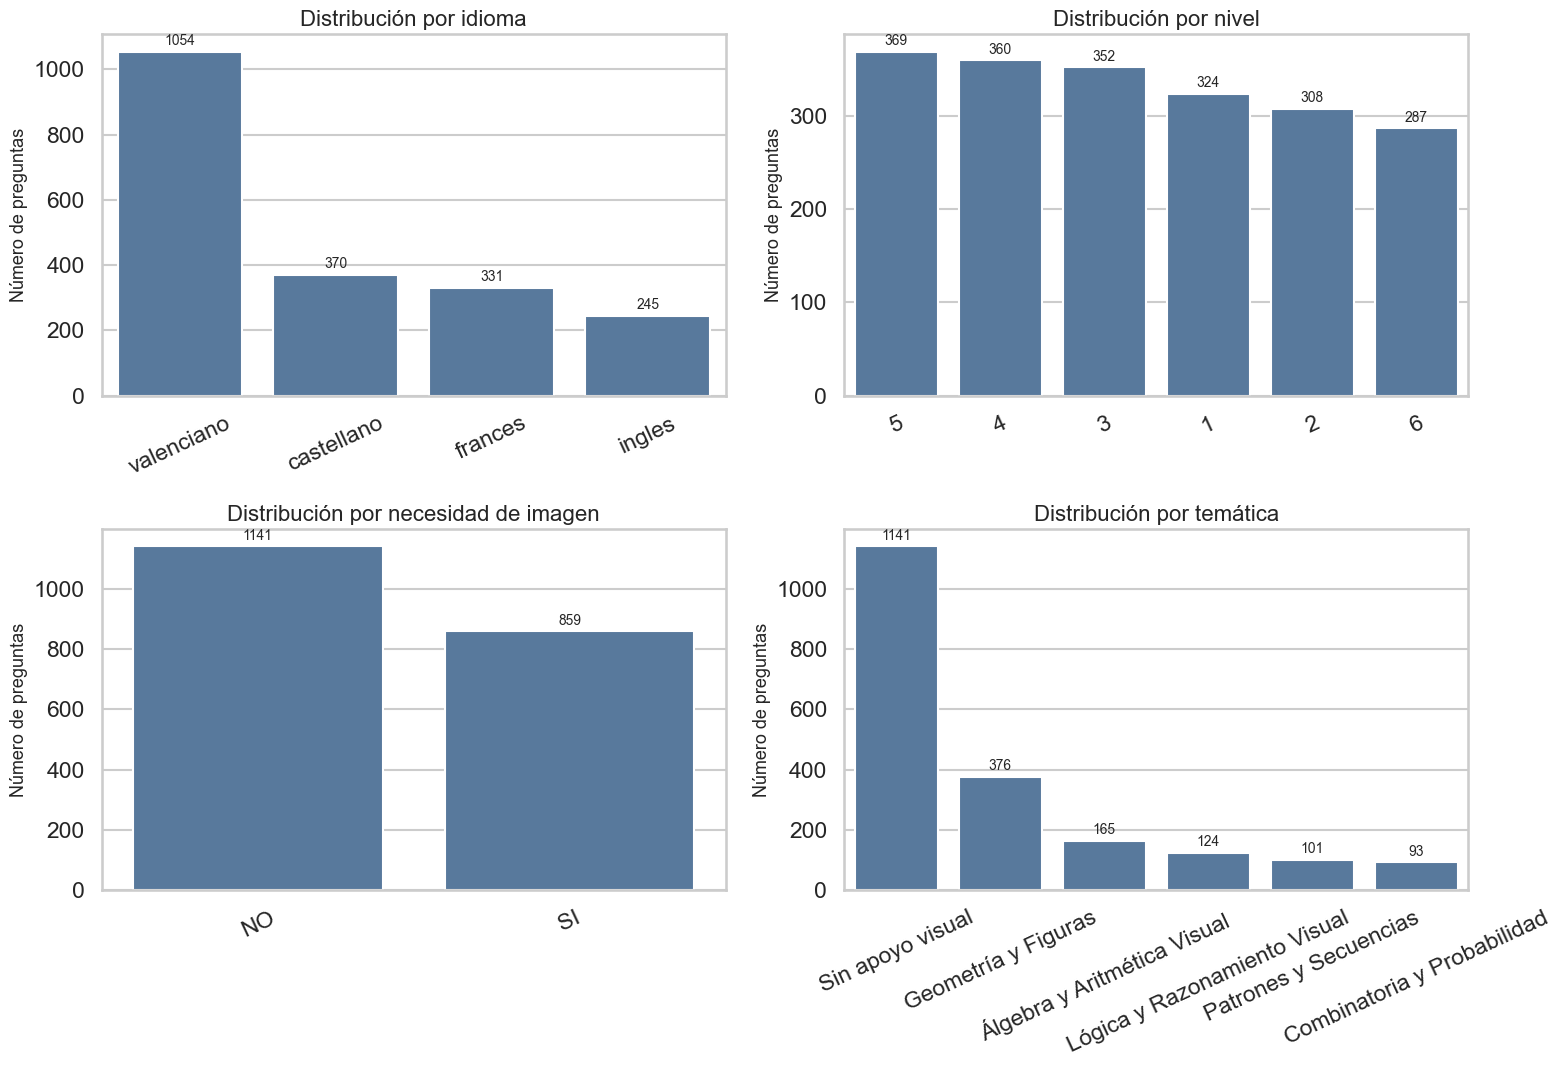

In [3]:
distribution_specs = [
    ("idioma", "Distribución por idioma"),
    ("Nivel", "Distribución por nivel"),
    ("Imagen", "Distribución por necesidad de imagen"),
    ("Tematica_filled", "Distribución por temática"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, (column, title) in zip(axes.flat, distribution_specs):
    counts = df[column].value_counts(dropna=False)
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Número de preguntas")
    ax.tick_params(axis="x", rotation=25)
    for i, value in enumerate(counts.values):
        ax.text(i, value + max(counts.values) * 0.01, str(value), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

### Comentario

Tras el control de calidad se analizan **2.000** preguntas de las
**2.009** filas originales. Se excluyen **9**
filas porque son casos minoritarios que pueden contaminar métricas agregadas: tres preguntas con opciones visuales
no transcritas, una pregunta con cuatro opciones, dos etiquetas incorrectas en una referencia con `ground truth`
conflictivo, dos filas de una referencia ambigua y un duplicado exacto.

De la base depurada, **859** preguntas requieren imagen
(43.0%) y **1.141** no la requieren.
La distribución no es uniforme: valenciano aporta la mayor parte del conjunto y `Sin apoyo visual`
es la categoría temática dominante porque en el CSV la temática solo está etiquetada para las preguntas visuales.

Esto importa mucho para interpretar cualquier media global: un resultado agregado alto puede venir,
en parte, de que hay más preguntas sin imagen y de que ciertos idiomas concentran más ejemplos que otros.

**Explicación celda**

Analiza la estructura de las preguntas antes de mirar respuestas de modelos.
Mide la longitud del enunciado, la cantidad de texto en las opciones, la distribución de la respuesta correcta
y posibles referencias duplicadas o conflictivas dentro del dataset.

,preguntas,mediana_palabras_enunciado,media_palabras_enunciado,mediana_palabras_opciones,porcentaje_5_opciones,porcentaje_opciones_casi_sin_texto
Imagen,,,,,,
SI,859,37.0,38.87,5.0,99.88,5.59
NO,1141,35.0,38.17,5.0,99.74,0.26


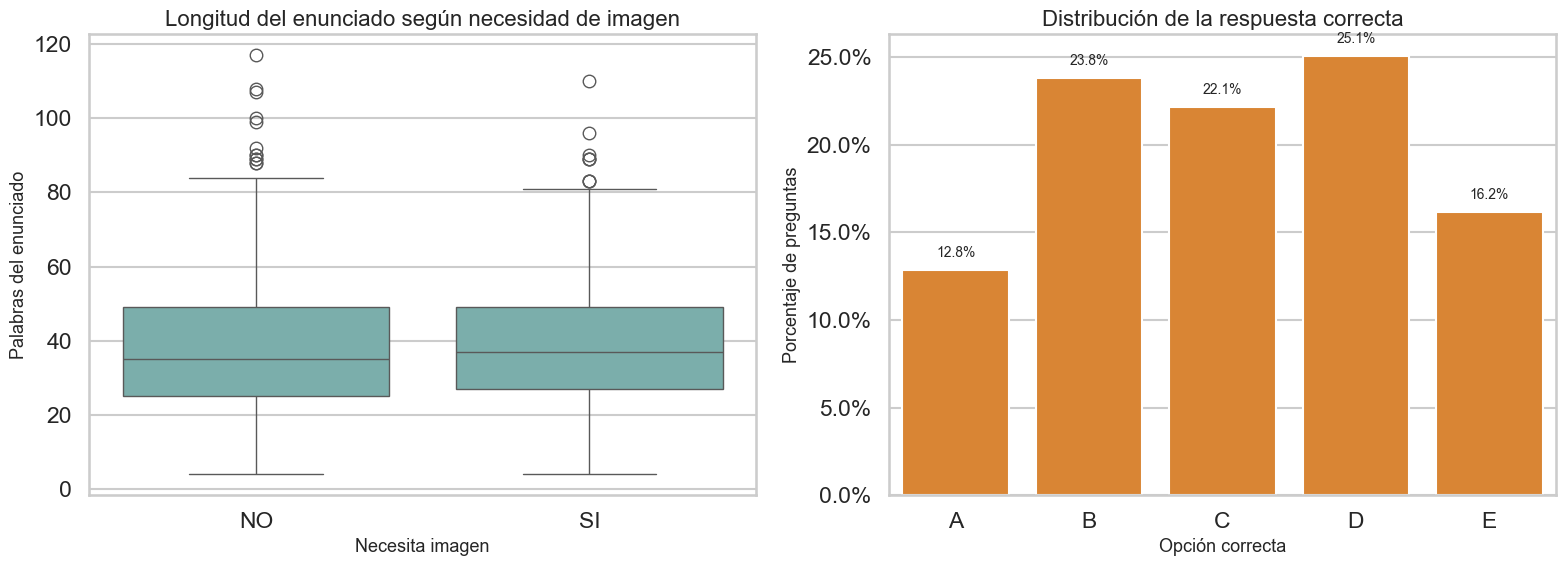

,filas,idiomas,respuestas_correctas_distintas,niveles_distintos,imagen_distinta,tematicas_distintas
Referencia,,,,,,


In [4]:
import re


def count_words(value) -> int:
    text = "" if pd.isna(value) else str(value)
    return len(re.findall(r"[\wÀ-ÿ]+", text))


def strip_option_labels(value) -> str:
    text = "" if pd.isna(value) else str(value)
    text = re.sub(r"\b[A-E]\s*\)", " ", text)
    text = re.sub(r"\b[A-E]\s*[:.]", " ", text)
    return text.strip()


question_profile = df.loc[:, ["Referencia", "idioma", "Imagen", "Tematica", "Nivel", "ground truth"]].copy()
question_profile["palabras_enunciado"] = df["Enunciado"].map(count_words)
question_profile["palabras_opciones"] = df["Opciones"].map(lambda value: count_words(strip_option_labels(value)))
question_profile["num_opciones"] = df["Opciones"].fillna("").astype(str).str.count(r"\b[A-E]\s*\)")
question_profile["opciones_casi_sin_texto"] = question_profile["palabras_opciones"].le(2)

structural_summary = (
    question_profile.groupby("Imagen")
    .agg(
        preguntas=("Referencia", "size"),
        mediana_palabras_enunciado=("palabras_enunciado", "median"),
        media_palabras_enunciado=("palabras_enunciado", "mean"),
        mediana_palabras_opciones=("palabras_opciones", "median"),
        porcentaje_5_opciones=("num_opciones", lambda values: values.eq(5).mean() * 100),
        porcentaje_opciones_casi_sin_texto=("opciones_casi_sin_texto", "mean"),
    )
    .reindex(["SI", "NO"])
)
structural_summary["porcentaje_opciones_casi_sin_texto"] *= 100

display(structural_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=question_profile, x="Imagen", y="palabras_enunciado", ax=axes[0], color="#72b7b2")
axes[0].set_title("Longitud del enunciado según necesidad de imagen")
axes[0].set_xlabel("Necesita imagen")
axes[0].set_ylabel("Palabras del enunciado")

gt_counts = question_profile["ground truth"].value_counts(normalize=True).reindex(list("ABCDE"), fill_value=0) * 100
sns.barplot(x=gt_counts.index, y=gt_counts.values, ax=axes[1], color="#f58518")
axes[1].set_title("Distribución de la respuesta correcta")
axes[1].set_xlabel("Opción correcta")
axes[1].set_ylabel("Porcentaje de preguntas")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, value in enumerate(gt_counts.values):
    axes[1].text(i, value + 0.6, f"{value:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

reference_control = (
    question_profile.groupby("Referencia")
    .agg(
        filas=("Referencia", "size"),
        idiomas=("idioma", "nunique"),
        respuestas_correctas_distintas=("ground truth", "nunique"),
        niveles_distintos=("Nivel", "nunique"),
        imagen_distinta=("Imagen", "nunique"),
        tematicas_distintas=("Tematica", lambda values: values.fillna("Sin apoyo visual").nunique()),
    )
    .sort_values(["filas", "respuestas_correctas_distintas"], ascending=False)
)

duplicate_references = reference_control.loc[reference_control["filas"].gt(1)]
display(duplicate_references)

### Comentario

Este control aporta dos lecturas útiles sobre las preguntas. Primero, la longitud textual no explica por sí sola
la diferencia entre preguntas visuales y no visuales: la mediana del enunciado es muy parecida
(**37** palabras con imagen frente a
**35** sin imagen), y la mediana del texto de opciones
también es similar. Por tanto, la caída observada en preguntas visuales no parece venir simplemente de que
tengan enunciados más largos.

Segundo, el formato de opción múltiple es muy estable: el **99.8%** de las filas
tiene cinco opciones detectables. La distribución de la respuesta correcta no es uniforme
(**A: 12.8%**, **B: 23.8%**,
**C: 22.1%**, **D: 25.1%**,
**E: 16.2%**), lo que conviene tener presente cuando se estudian
sesgos de salida por opción.

Finalmente, después del filtro inicial ya no quedan referencias duplicadas ni referencias con respuestas correctas
conflictivas dentro de la base analizada. Esto evita que unas pocas filas anómalas tengan un efecto artificial
sobre las métricas posteriores.

**Explicación celda**

Muestra las preguntas que todavía no tienen exactamente cinco etiquetas detectables de opción después del filtro.
Estas filas sirven para distinguir errores reales de limitaciones del detector textual de opciones.

In [5]:
problematic_options = (
    question_profile.loc[question_profile["num_opciones"].ne(5)]
    .merge(df.loc[:, ["Referencia", "Enunciado", "Opciones"]], on="Referencia", how="left")
    .loc[:, ["Referencia", "idioma", "Imagen", "Tematica", "Nivel", "ground truth", "num_opciones", "Enunciado", "Opciones"]]
    .drop_duplicates()
    .sort_values(["num_opciones", "Referencia"])
)

print(f"Filas con número de opciones distinto de 5: {len(problematic_options)}")
display(problematic_options)

Filas con número de opciones distinto de 5: 4


,Referencia,idioma,Imagen,Tematica,Nivel,ground truth,num_opciones,Enunciado,Opciones
2,2014_Student_11,ingles,NO,NaN,5,A,8,"A cuboid-shaped box has the measurements a × b × c with a < b < c. If one increases a or b or c by 5 cm, the volume of the box increases...","(A) If one increases a. (B) If one increases b. (C) If one increases c. (D) The answer is depending on the values of a, b and c. (E) The..."
1,2015_Student_21,ingles,NO,NaN,5,D,9,Die Aussagen (A) – (E) werden der Reihe nach auf ihre Wahrheit überprüft. Welche davon ist die erste wahre Aussage?,(A) (C) is true. (B) (A) is true. (C) (E) is false. (D) (B) is false. (E)) 1+1 = 2
0,2015_nivel6_23,castellano,NO,NaN,6,D,9,"Cuando se lean las siguientes proposiciones de izquierda a derecha, ¿cuál es la primera proposición que es cierta?",A) C) es cierta B) A) es cierta C) E) es falsa D) B) es falsa E) 1+1=2
3,2015_nivell6_26,valenciano,SI,Álgebra y Aritmética Visual,6,C,11,Una barca sura en un port i una persona fa servir una maroma prou llarga per a atraure la barca cap a la vora tal com mostra la figura. ...,A) És de menys d'un metre B) És exactament un metre C) És de més d'un metre D) Sense conèixer la longitud de la maroma no podem decidir ...


### Análisis de las filas con opciones no estándar

Después de eliminar la pregunta real de cuatro opciones (`2015_nivel2_7`) y las tres preguntas con opciones visuales
no transcritas (`2020_nivel1_1`, `2020_nivel1_21` y `2020_nivel3_2`), las filas restantes no parecen errores
que deban borrarse automáticamente.

Las filas que todavía aparecen tienen `num_opciones` superior a cinco, pero no necesariamente están mal formadas.
En `2015_nivel6_23` y
`2015_Student_21`, las opciones son autorreferenciales y mencionan otras opciones dentro del propio texto
(`A)`, `B)`, `C)`, etc.), por eso el detector cuenta más etiquetas de las que realmente hay. Algo parecido ocurre en
`2015_nivell6_26`, donde las opciones `D` y `E` mencionan explícitamente `A)`, `B)` y `C)`. En estos casos,
el formato de la pregunta es válido; lo que falla es una regla simple de conteo basada solo en expresiones regulares.

**Explicación celda**

Comprueba si quedan referencias duplicadas después del filtro de calidad.
Si la limpieza ha funcionado, esta tabla debe quedar vacía.

In [6]:
duplicate_reference_ids = duplicate_references.index.tolist()
duplicated_questions = (
    question_profile.loc[question_profile["Referencia"].isin(duplicate_reference_ids)]
    .merge(df.loc[:, ["Referencia", "Enunciado", "Opciones"]], on="Referencia", how="left")
    .assign(
        conflicto_ground_truth=lambda data: data.groupby("Referencia")["ground truth"].transform("nunique").gt(1)
    )
    .loc[:, ["Referencia", "conflicto_ground_truth", "idioma", "Imagen", "Tematica", "Nivel", "ground truth", "Enunciado", "Opciones"]]
    .drop_duplicates()
    .sort_values(["conflicto_ground_truth", "Referencia", "ground truth"], ascending=[False, True, True])
)

print(f"Referencias duplicadas: {len(duplicate_reference_ids)}")
print(f"Referencias duplicadas con ground truth conflictivo: {duplicated_questions.loc[duplicated_questions['conflicto_ground_truth'], 'Referencia'].nunique()}")
display(duplicated_questions)

Referencias duplicadas: 0
Referencias duplicadas con ground truth conflictivo: 0


,Referencia,conflicto_ground_truth,idioma,Imagen,Tematica,Nivel,ground truth,Enunciado,Opciones


### Análisis de las referencias duplicadas

Tras la limpieza, la tabla queda vacía. La decisión aplicada ha sido conservadora: en `2018_nivell2_10` se elimina
solo la segunda aparición porque parece un duplicado exacto; en `2017_nivell6_1` se conservó únicamente la fila con
respuesta `B`, ya que el enunciado permite verificar esa solución; y `2018_nivell1_11` se eliminó por completo porque
combina conflicto de `ground truth` con una posible mala etiqueta de dependencia visual.

**Explicación celda**

Calcula las métricas globales por modelo, separando preguntas con imagen y sin imagen.
Además, dibuja dos comparativas: precisión por modalidad y tasa de `No Answer` por modalidad.

,Modelo,% acierto con imagen,% acierto sin imagen,% No Answer con imagen,% No Answer sin imagen
0,Gemini 2.0 Flash,40.98,74.50,17.93,9.82
1,Qwen-VL 72B,41.44,71.17,0.12,0.00
2,GPT-4o,35.86,64.94,6.87,5.87
3,Gemini 2.0 Flash Lite,35.74,63.89,17.46,12.53
4,Qwen-VL 7B,30.27,48.38,0.58,1.31
5,Pixtral Large,27.24,41.10,15.95,14.20
6,Pixtral-12B,22.58,27.61,10.13,11.39
7,Llama 3.2 90B Vision Instruct,15.02,17.00,20.02,23.14
8,Llama 3.2 11B Vision Instruct,8.27,12.45,33.18,35.76


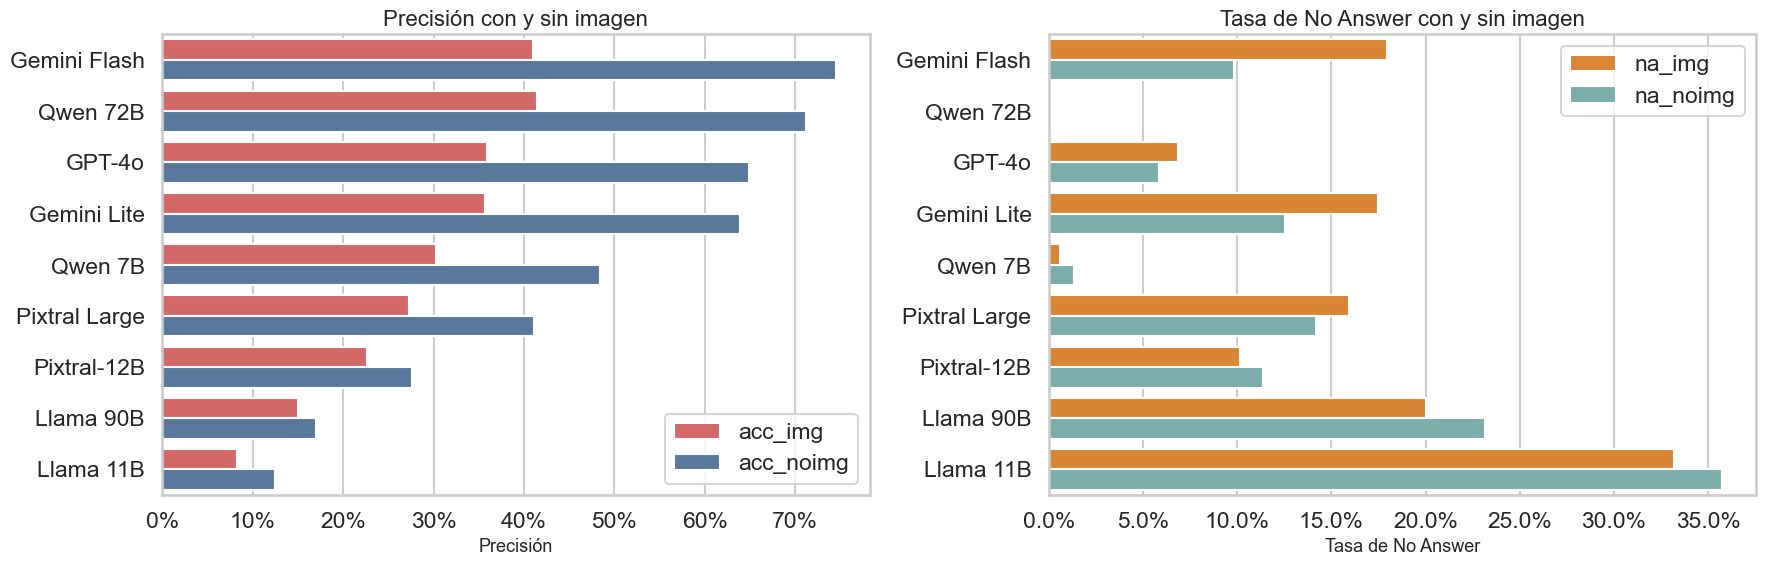

In [7]:
summary_global = (
    long_df.groupby("model")
    .agg(
        acc_global=("is_correct", "mean"),
        no_answer_rate=("is_no_answer", "mean"),
    )
    .reset_index()
)

by_image = (
    long_df.groupby(["model", "Imagen"])
    .agg(acc=("is_correct", "mean"), no_answer=("is_no_answer", "mean"))
    .reset_index()
)

summary_global = summary_global.merge(
    by_image.pivot(index="model", columns="Imagen", values="acc").rename(columns={"SI": "acc_img", "NO": "acc_noimg"}),
    left_on="model",
    right_index=True,
)
summary_global = summary_global.merge(
    by_image.pivot(index="model", columns="Imagen", values="no_answer").rename(columns={"SI": "na_img", "NO": "na_noimg"}),
    left_on="model",
    right_index=True,
)
summary_global["gap_img_text"] = summary_global["acc_noimg"] - summary_global["acc_img"]
summary_global["answered_accuracy"] = (
    long_df.loc[~long_df["is_no_answer"]]
    .groupby("model")["is_correct"]
    .mean()
    .reindex(summary_global["model"])
    .to_numpy()
)

summary_global = summary_global.set_index("model").loc[MODEL_ORDER].reset_index()

summary_by_image = summary_global.loc[
    :,
    ["model", "acc_img", "acc_noimg", "na_img", "na_noimg"],
].rename(
    columns={
        "model": "Modelo",
        "acc_img": "% acierto con imagen",
        "acc_noimg": "% acierto sin imagen",
        "na_img": "% No Answer con imagen",
        "na_noimg": "% No Answer sin imagen",
    }
)

display((summary_by_image.assign(**{
    "% acierto con imagen": lambda x: (x["% acierto con imagen"] * 100).round(2),
    "% acierto sin imagen": lambda x: (x["% acierto sin imagen"] * 100).round(2),
    "% No Answer con imagen": lambda x: (x["% No Answer con imagen"] * 100).round(2),
    "% No Answer sin imagen": lambda x: (x["% No Answer sin imagen"] * 100).round(2),
})))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_df = summary_global.copy()
plot_df["model_short"] = plot_df["model"].map(MODEL_SHORT)

sns.barplot(
    data=plot_df.melt(id_vars=["model_short"], value_vars=["acc_img", "acc_noimg"], var_name="subset", value_name="value"),
    x="value",
    y="model_short",
    hue="subset",
    ax=axes[0],
    palette=["#e45756", "#4c78a8"],
)
axes[0].set_title("Precisión con y sin imagen")
axes[0].set_xlabel("Precisión")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend(title="")

sns.barplot(
    data=plot_df.melt(id_vars=["model_short"], value_vars=["na_img", "na_noimg"], var_name="subset", value_name="value"),
    x="value",
    y="model_short",
    hue="subset",
    ax=axes[1],
    palette=["#f58518", "#72b7b2"],
)
axes[1].set_title("Tasa de No Answer con y sin imagen")
axes[1].set_xlabel("Tasa de No Answer")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(title="")

plt.tight_layout()
plt.show()

### Comentario

La tabla siguiente resume el comportamiento global con y sin imagen. El mejor modelo global es **Gemini 2.0 Flash**
con una precisión total del **60.1%**, seguido muy de cerca por
**Qwen-VL 72B** con **58.4%**.

La caída entre texto y visión no es homogénea. La brecha más grande aparece en
**Gemini 2.0 Flash** (**33.5** puntos porcentuales entre preguntas sin imagen y con imagen),
mientras que la menor está en **Llama 3.2 90B Vision Instruct** (**2.0** p.p.).
Esto sugiere algo importante: los modelos fuertes sí mejoran mucho cuando el problema se vuelve esencialmente textual,
mientras que los Llama rinden mal en ambos entornos y, por tanto, apenas muestran diferencia.

**Explicación celda**

Desglosa la precisión por idioma y por necesidad de imagen.
Primero construye una tabla compacta con ambos valores y luego muestra dos mapas de calor: uno para preguntas con imagen
y otro para preguntas sin imagen.

idioma,castellano,frances,ingles,valenciano
model,,,,
Gemini Flash,45.5 / 75.2,38.2 / 71.4,37.0 / 75.4,41.6 / 74.8
Qwen 72B,41.7 / 68.2,36.5 / 69.6,37.0 / 74.6,44.8 / 71.9
GPT-4o,41.0 / 62.6,24.7 / 64.6,30.7 / 60.2,40.1 / 66.7
Gemini Lite,40.4 / 58.9,33.5 / 60.2,32.3 / 61.0,36.0 / 67.0
Qwen 7B,33.3 / 48.1,22.9 / 49.1,29.9 / 52.5,32.3 / 47.5
Pixtral Large,22.4 / 36.0,27.1 / 43.5,29.1 / 55.9,28.6 / 39.5
Pixtral-12B,20.5 / 20.1,22.4 / 26.7,23.6 / 39.8,23.2 / 28.1
Llama 90B,11.5 / 14.0,17.1 / 22.4,24.4 / 38.1,12.6 / 12.8
Llama 11B,9.0 / 10.3,6.5 / 13.0,5.5 / 22.9,9.6 / 11.1


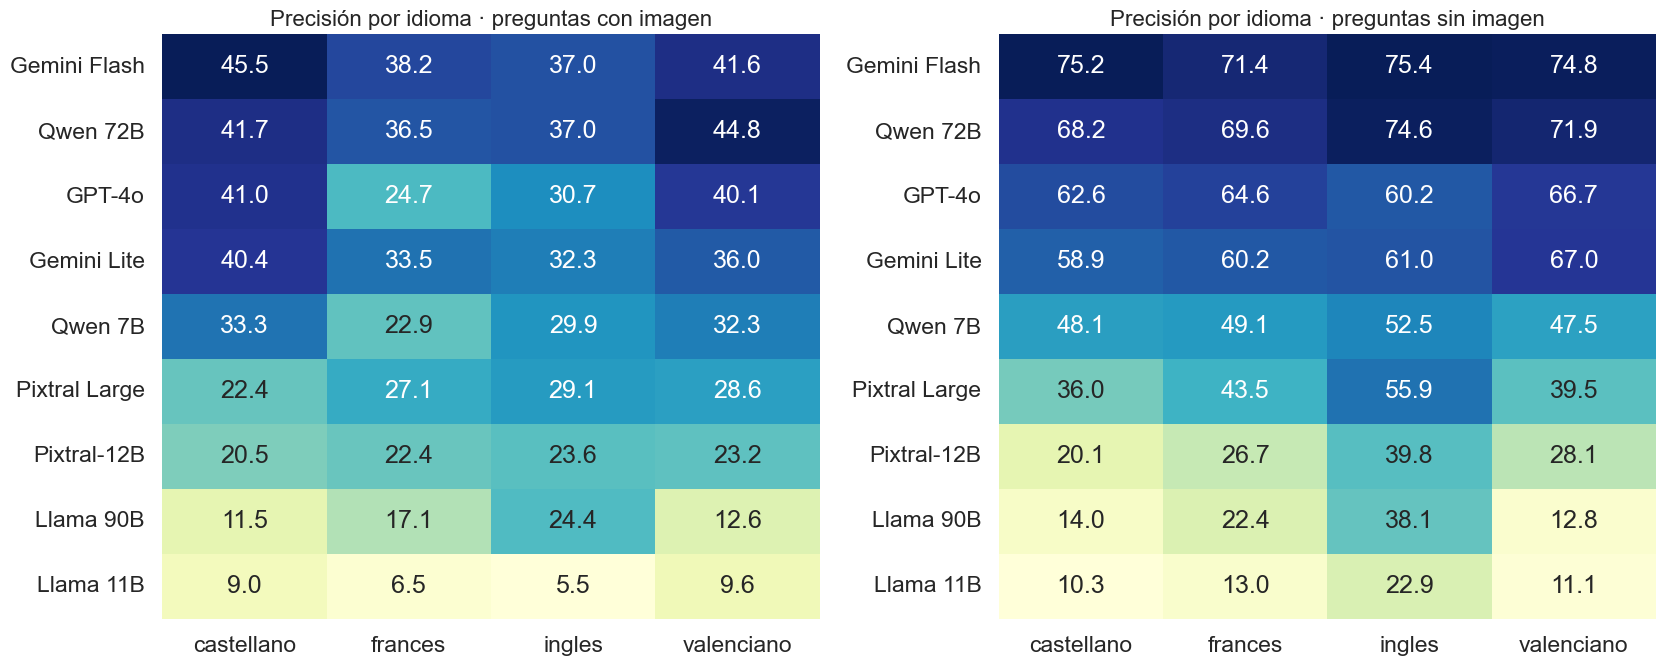

In [8]:
table4_parts = (
    long_df.groupby(["model", "idioma", "Imagen"])["is_correct"]
    .mean()
    .reset_index()
    .pivot_table(index=["model", "idioma"], columns="Imagen", values="is_correct")
    .rename(columns={"SI": "con_imagen", "NO": "sin_imagen"})
    .reset_index()
)

table4_parts["resultado"] = table4_parts.apply(
    lambda row: f"{row['con_imagen'] * 100:.1f} / {row['sin_imagen'] * 100:.1f}",
    axis=1,
)

table4 = (
    table4_parts.pivot(index="model", columns="idioma", values="resultado")
    .loc[MODEL_ORDER]
    .rename(index=MODEL_SHORT)
)

display(table4)

heatmap_img = (
    long_df.loc[long_df["Imagen"].eq("SI")]
    .groupby(["model", "idioma"])["is_correct"]
    .mean()
    .unstack()
    .loc[MODEL_ORDER]
    .rename(index=MODEL_SHORT)
)
heatmap_noimg = (
    long_df.loc[long_df["Imagen"].eq("NO")]
    .groupby(["model", "idioma"])["is_correct"]
    .mean()
    .unstack()
    .loc[MODEL_ORDER]
    .rename(index=MODEL_SHORT)
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(heatmap_img * 100, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar=False)
axes[0].set_title("Precisión por idioma · preguntas con imagen")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(heatmap_noimg * 100, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1], cbar=False)
axes[1].set_title("Precisión por idioma · preguntas sin imagen")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Comentario

En media simple por idioma, la precisión más alta aparece en **valenciano**
(40.2%) y la más baja en **frances**
(35.8%). Aun así, aquí conviene ser prudente: los idiomas no comparten exactamente
las mismas preguntas, así que esta comparación refleja mezcla de idioma y composición del subconjunto.

Donde sí hay una pauta clara es en la modalidad. En todos los idiomas, la columna “sin imagen”
es bastante más alta que la de “con imagen” para los modelos fuertes. El francés emerge como el subconjunto
comparativamente más duro y valenciano/castellano suelen sostener mejores resultados en los mejores modelos.

**Explicación celda**

Construye un radar por idioma para visualizar cómo cambia la precisión de cada modelo a lo largo de los distintos niveles.
La idea es ver si hay patrones de degradación o mejora que no se aprecian en una media global.

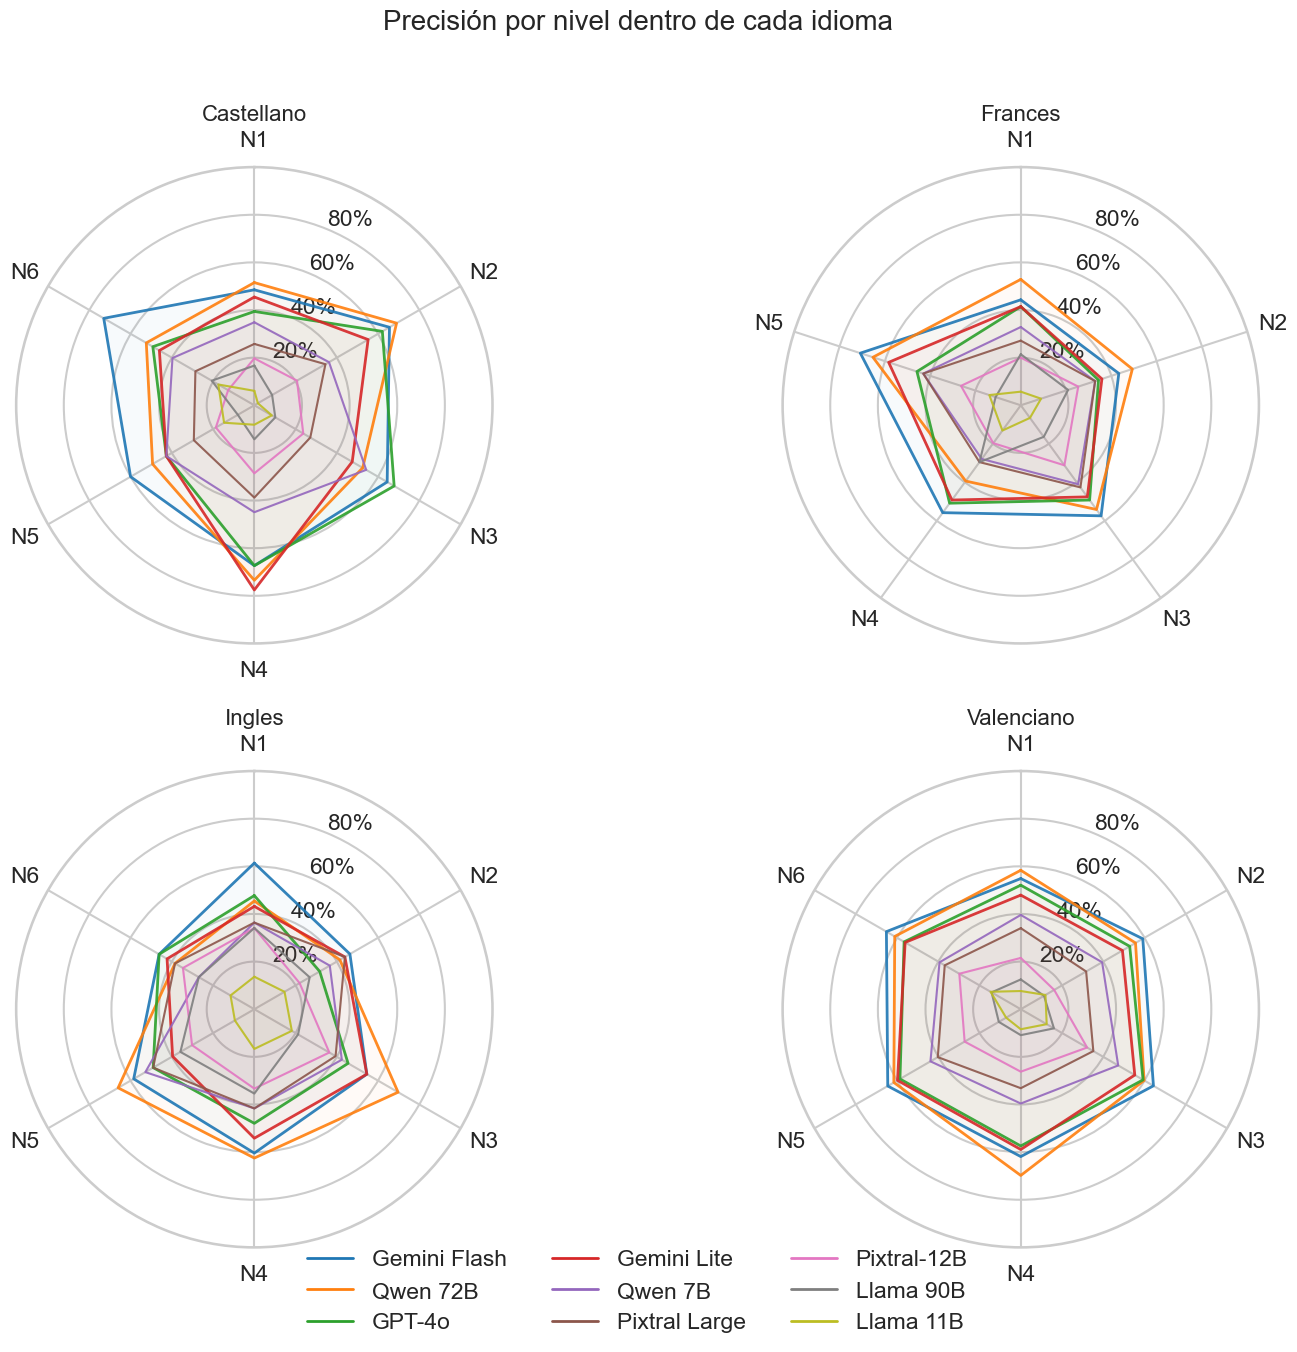

In [9]:
language_level_tables = {}
for language in sorted(df["idioma"].unique()):
    table = (
        long_df.loc[long_df["idioma"].eq(language)]
        .groupby(["model", "Nivel"])["is_correct"]
        .mean()
        .unstack()
        .reindex(MODEL_ORDER)
    )
    language_level_tables[language] = table

fig, axes = plt.subplots(2, 2, subplot_kw={"polar": True}, figsize=(16, 14))
for ax, language in zip(axes.flat, sorted(language_level_tables)):
    radar_plot(ax, language_level_tables[language], language)

handles = [plt.Line2D([0], [0], color=PALETTE[model], lw=2) for model in MODEL_ORDER]
labels = [MODEL_SHORT[model] for model in MODEL_ORDER]
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02))
fig.suptitle("Precisión por nivel dentro de cada idioma", y=0.98, fontsize=20)
plt.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

**Explicación celda**

Cuenta cuántas preguntas con imagen y sin imagen hay en cada nivel y lo representa en barras agrupadas.
Esta celda sirve para contextualizar el radar anterior y separar dificultad escolar de composición visual del dataset.

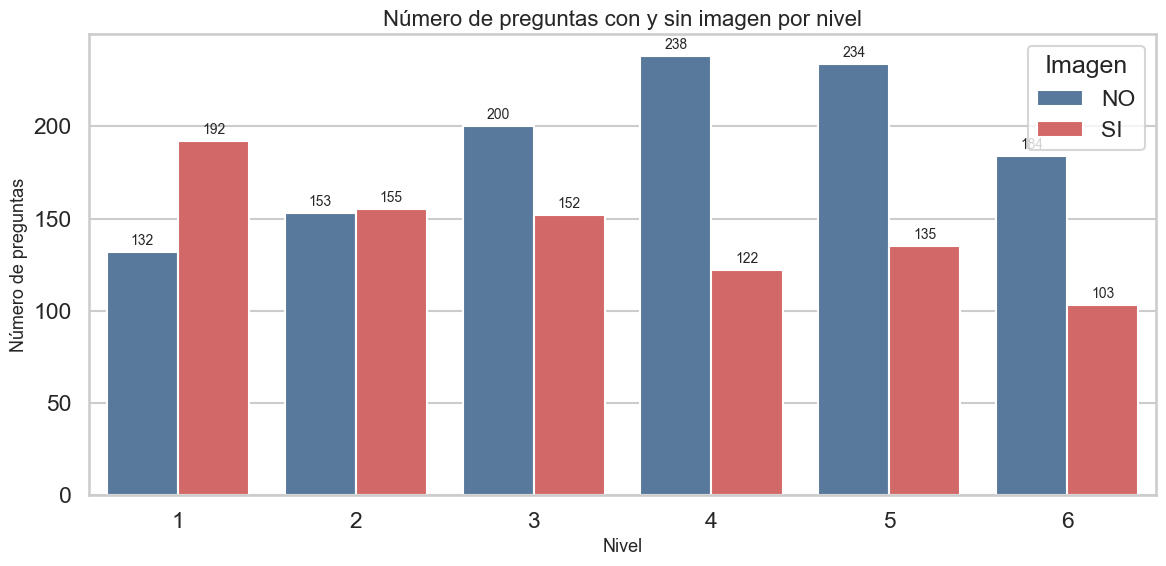

In [10]:
level_image_counts = (
    df.groupby(["Nivel", "Imagen"])
    .size()
    .reset_index(name="n")
    .sort_values(["Nivel", "Imagen"])
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=level_image_counts,
    x="Nivel",
    y="n",
    hue="Imagen",
    palette={"SI": "#e45756", "NO": "#4c78a8"},
)
ax.set_title("Número de preguntas con y sin imagen por nivel")
ax.set_xlabel("Nivel")
ax.set_ylabel("Número de preguntas")
ax.legend(title="Imagen")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=10)

plt.tight_layout()
plt.show()

### Comentario

Este bloque combina dos lecturas: el radar muestra el rendimiento por nivel dentro de cada idioma
y la gráfica de barras muestra cuántas preguntas con y sin imagen hay en cada nivel.
La pauta más llamativa es que la precisión media **no cae** al subir el nivel; de hecho, la media más alta está en
**nivel 3** (41.3%) y la más baja en **nivel 1**
(34.9%).

La gráfica de recuentos ayuda a entender por qué ocurre esto. En los niveles bajos hay más peso visual:
por ejemplo, en **nivel 1** hay **192** preguntas con imagen frente a
**132** sin imagen. En cambio, en los niveles altos domina más el bloque no visual:
en **nivel 4** hay **238** sin imagen frente a **122** con imagen,
y en **nivel 6** hay **184** sin imagen frente a **103** con imagen.

Eso no implica que los niveles altos sean “más fáciles” en sentido pedagógico. Lo que sugiere es que, en este dataset,
la dificultad escolar y la dificultad visual no coinciden exactamente: a medida que sube el nivel, aumenta el peso relativo
de preguntas que pueden resolverse sin depender tanto de la figura.

**Explicación celda**

Estudia el rendimiento en las temáticas visuales etiquetadas.
Muestra una tabla de precisión por modelo y temática, un mapa de calor y un gráfico con la precisión media por temática.

model,Gemini 2.0 Flash,Qwen-VL 72B,GPT-4o,Gemini 2.0 Flash Lite,Qwen-VL 7B,Pixtral Large,Pixtral-12B,Llama 3.2 90B Vision Instruct,Llama 3.2 11B Vision Instruct
Tematica,,,,,,,,,
Combinatoria y Probabilidad,35.48,44.09,31.18,34.41,25.81,29.03,23.66,13.98,5.38
Geometría y Figuras,45.21,44.15,41.76,39.36,34.84,29.79,21.28,15.43,9.84
Lógica y Razonamiento Visual,29.03,37.90,29.84,32.26,24.19,25.81,26.61,12.10,6.45
Patrones y Secuencias,37.62,38.61,31.68,32.67,24.75,21.78,17.82,20.79,8.91
Álgebra y Aritmética Visual,45.45,38.18,32.12,32.73,30.30,24.85,24.85,13.33,7.27


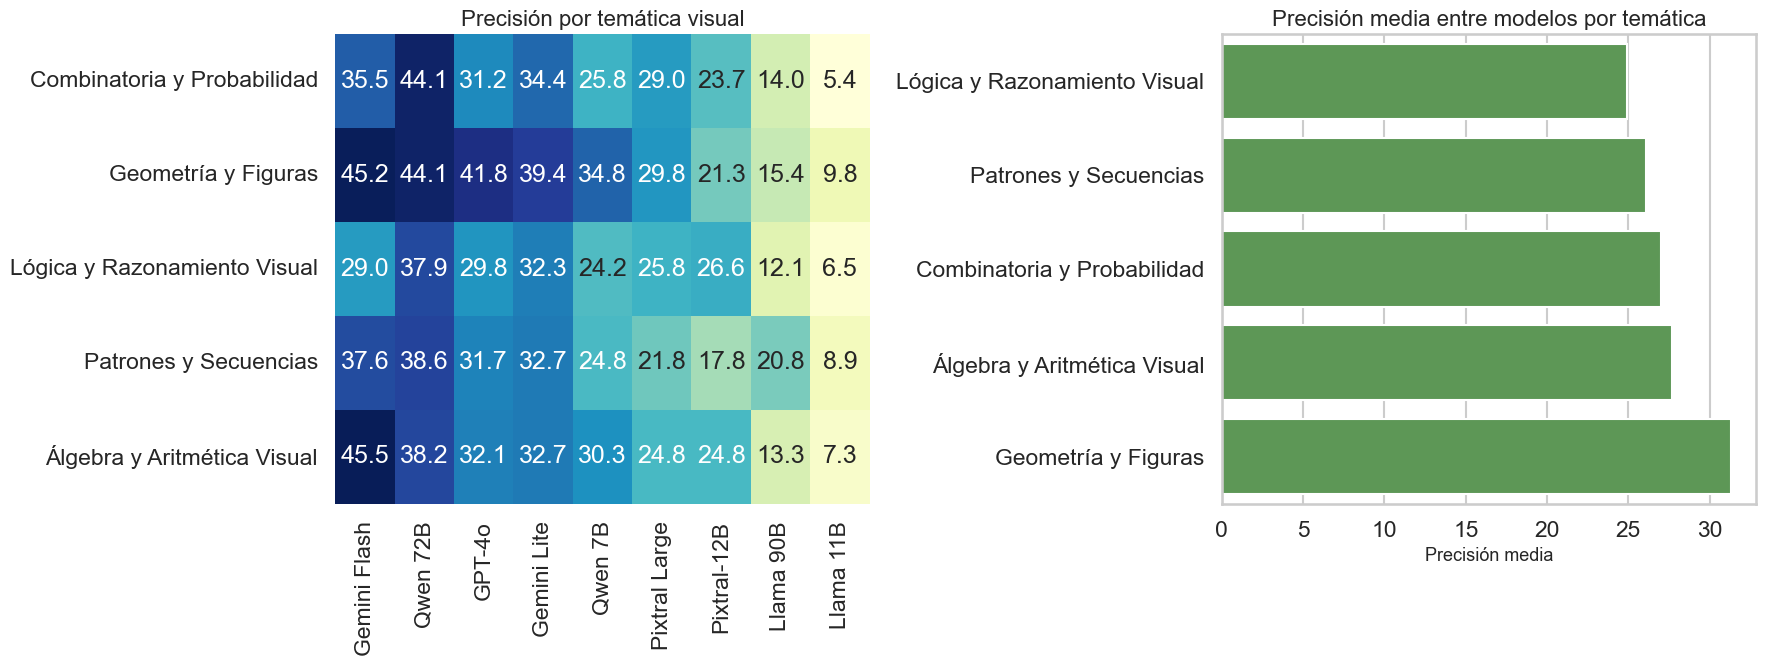

In [11]:
topic_accuracy = (
    long_df.loc[long_df["Imagen"].eq("SI")]
    .groupby(["Tematica", "model"])["is_correct"]
    .mean()
    .unstack()
    .reindex(columns=MODEL_ORDER)
)

display((topic_accuracy * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(topic_accuracy.loc[:, MODEL_ORDER].rename(columns=MODEL_SHORT) * 100, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar=False)
axes[0].set_title("Precisión por temática visual")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

topic_avg = topic_accuracy.mean(axis=1).sort_values()
sns.barplot(x=topic_avg.values * 100, y=topic_avg.index, ax=axes[1], color="#54a24b")
axes[1].set_title("Precisión media entre modelos por temática")
axes[1].set_xlabel("Precisión media")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Comentario

La matriz temática muestra que la temática visual más difícil en promedio es
**Lógica y Razonamiento Visual** (24.9% de precisión media entre modelos),
mientras que la más asequible es **Geometría y Figuras** (31.3%).

Además, no hay un campeón universal. En esta base:

- **Qwen-VL 72B** lidera en **Combinatoria y Probabilidad**.
- **Gemini 2.0 Flash** lidera en **Geometría y Figuras**.
- **Qwen-VL 72B** lidera en **Lógica y Razonamiento Visual**.

La lectura sustantiva es clara: geometría sale relativamente mejor que lógica visual, pero ninguna familia domina en todos los frentes.

**Explicación celda**

Analiza las columnas de razonamiento (`reasoning ...`) de `DatasetFull.csv` sobre el dataset ya limpio. El objetivo no es medir si el razonamiento es correcto, sino comprobar si existen trazas para todos los modelos, comparar su longitud media, mediana y desviación típica, y observar qué vocabulario aparece con más frecuencia. Para que el recuento sea interpretable, se normalizan términos equivalentes en varios idiomas, por ejemplo `número`, `nombre` y `number` como `number`, y se eliminan conectores frecuentes que no aportan contenido matemático.


In [21]:
REASONING_STOPWORDS = {
    "about", "above", "after", "again", "against", "also", "because", "been", "being", "between",
    "cannot", "could", "does", "each", "from", "have", "into", "more", "must", "only", "option",
    "options", "problem", "question", "should", "that", "their", "there", "therefore", "these",
    "this", "those", "through", "with", "would", "answer", "correct", "incorrect",
    "ademas", "algunas", "algunos", "ambos", "como", "con", "cuando", "debe", "deben", "desde",
    "donde", "esta", "este", "esto", "forma", "haber", "hace", "hacia", "hasta", "imagen", "lado",
    "mismo", "opcion", "opciones", "para", "pero", "porque", "pregunta", "problema", "puede",
    "pueden", "respuesta", "segun", "sobre", "solo", "tambien", "tiene", "tienen", "todas",
    "todos", "una", "uno", "valor", "cdot", "frac", "left", "right", "text", "times", "plus",
    "aixo", "això", "aquesta", "aquest", "cada", "dels", "donc", "entre", "nous", "pour",
    "raonament", "resposta", "sqrt", "tant", "tres", "aixi", "així", "así", "calcular",
    "determinar", "dues", "igual", "podem", "possible", "primer", "tanto", "then",
}

REASONING_CANONICAL_TERMS = {
    "number": {"number", "numbers", "numero", "número", "numeros", "números", "nombre", "nombres"},
    "sum": {"sum", "suma", "somme"},
    "total": {"total", "totals"},
    "triangle": {"triangle", "triangles", "triangulo", "triángulo", "triangulos", "triángulos"},
    "square": {"square", "squares", "cuadrado", "cuadrados", "quadrat", "quadrats"},
    "area": {"area", "areas", "área", "àrea", "aire"},
    "angle": {"angle", "angles", "angulo", "ángulo", "angulos", "ángulos"},
    "side": {"side", "sides", "lado", "lados", "costat", "costats"},
    "figure": {"figure", "figures", "figura", "figuras"},
    "position": {"position", "positions", "posicion", "posición", "posiciones"},
    "pattern": {"pattern", "patterns", "patron", "patrón", "patrones"},
}
REASONING_TERM_LOOKUP = {
    variant: canonical
    for canonical, variants in REASONING_CANONICAL_TERMS.items()
    for variant in variants
}


def reasoning_word_count(text) -> int:
    return len(re.findall(r"[A-Za-zÀ-ÿ0-9]+", "" if pd.isna(text) else str(text)))


def reasoning_tokens(text) -> list[str]:
    tokens = []
    for raw_token in re.findall(r"[A-Za-zÀ-ÿ0-9]+", str(text)):
        token = raw_token.lower()
        if len(token) <= 3 or token.isdigit() or token in REASONING_STOPWORDS:
            continue
        tokens.append(REASONING_TERM_LOOKUP.get(token, token))
    return tokens


reasoning_rows = []
reasoning_global_counter = Counter()

for model in MODEL_ORDER:
    column = f"reasoning {model}"
    texts = df[column].fillna("").astype(str).str.strip()
    counts = texts.map(reasoning_word_count)
    non_empty = counts.gt(0)

    model_counter = Counter()
    for text in texts[non_empty]:
        tokens = reasoning_tokens(text)
        model_counter.update(tokens)
        reasoning_global_counter.update(tokens)

    reasoning_rows.append(
        {
            "model": model,
            "available_traces": int(non_empty.sum()),
            "empty_traces": int((~non_empty).sum()),
            "mean_words": round(float(counts[non_empty].mean()), 1),
            "median_words": round(float(counts[non_empty].median()), 1),
            "std_words": round(float(counts[non_empty].std(ddof=0)), 1),
            "top_terms": ", ".join(term for term, _ in model_counter.most_common(8)),
        }
    )

reasoning_summary = (
    pd.DataFrame(reasoning_rows)
    .sort_values("mean_words", ascending=False)
    .reset_index(drop=True)
)
reasoning_top_terms = pd.DataFrame(
    {
        "Most frequent normalized terms": [
            ", ".join(term for term, _ in reasoning_global_counter.most_common(20))
        ]
    }
)

display(reasoning_summary)
display(reasoning_top_terms)


,model,available_traces,empty_traces,mean_words,median_words,std_words,top_terms
0,Pixtral-12B,2000,0,204.5,167.0,540.6,"number, square, area, total, triangle, sum, segment, dividir"
1,Qwen-VL 7B,2000,0,203.7,169.0,262.6,"number, triangle, sum, square, total, area, angle, side"
2,Gemini 2.0 Flash,2000,0,200.2,133.0,183.8,"number, square, triangle, angle, area, total, side, sum"
3,Llama 3.2 90B Vision Instruct,2000,0,198.0,172.0,234.2,"number, triangle, total, square, area, sum, side, angle"
4,Pixtral Large,2000,0,195.9,190.0,84.3,"number, square, triangle, total, area, sum, side, angle"
5,GPT-4o,2000,0,172.7,166.5,66.3,"number, total, square, triangle, area, sum, side, angle"
6,Gemini 2.0 Flash Lite,2000,0,172.3,120.5,187.0,"number, area, triangle, angle, square, sum, total, side"
7,Qwen-VL 72B,2000,0,167.2,153.0,84.2,"number, triangle, square, total, area, sum, angle, side"
8,Llama 3.2 11B Vision Instruct,2000,0,165.8,153.0,104.2,"number, triangle, square, angle, total, side, sum, area"


,Most frequent normalized terms
0,"number, square, triangle, total, area, sum, angle, side, figure, rectangle, longitud, since, dans, trobar, base, need, gran, tenim, deux, circ"


### Comentario sobre las trazas de razonamiento

El análisis confirma que las nueve columnas de razonamiento están completas para las 2.000 preguntas del dataset de trabajo. Sin embargo, la longitud de las explicaciones varía de forma clara entre modelos: `Llama 3.2 11B Vision Instruct` es el más breve en media (165.8 palabras), mientras que `Pixtral-12B` y `Qwen-VL 7B` superan las 200 palabras de media. La desviación típica añade una lectura importante: `Pixtral-12B` combina razonamientos de longitud ordinaria con algunos outputs extremadamente largos, lo que explica una dispersión mucho mayor que la de modelos como `GPT-4o` o `Qwen-VL 72B`. Esto es relevante porque los modelos con razonamientos más largos o más variables no son necesariamente los más precisos; por tanto, la cantidad de texto no debe confundirse con calidad del razonamiento.

Los términos más frecuentes, una vez normalizados, se concentran en vocabulario matemático y geométrico general (`number`, `square`, `triangle`, `area`, `sum`, `angle`, `side`). Esta observación refuerza una idea importante del proyecto: muchos modelos producen explicaciones con apariencia matemática, pero el análisis posterior debe verificar si esas explicaciones están realmente conectadas con la evidencia visual del problema.


**Explicación celda**

Calcula tres matrices entre pares de modelos: aciertos simultáneos, fallos simultáneos y casos donde un modelo falla
mientras el otro acierta. Después las representa para ver coincidencias y complementariedad.

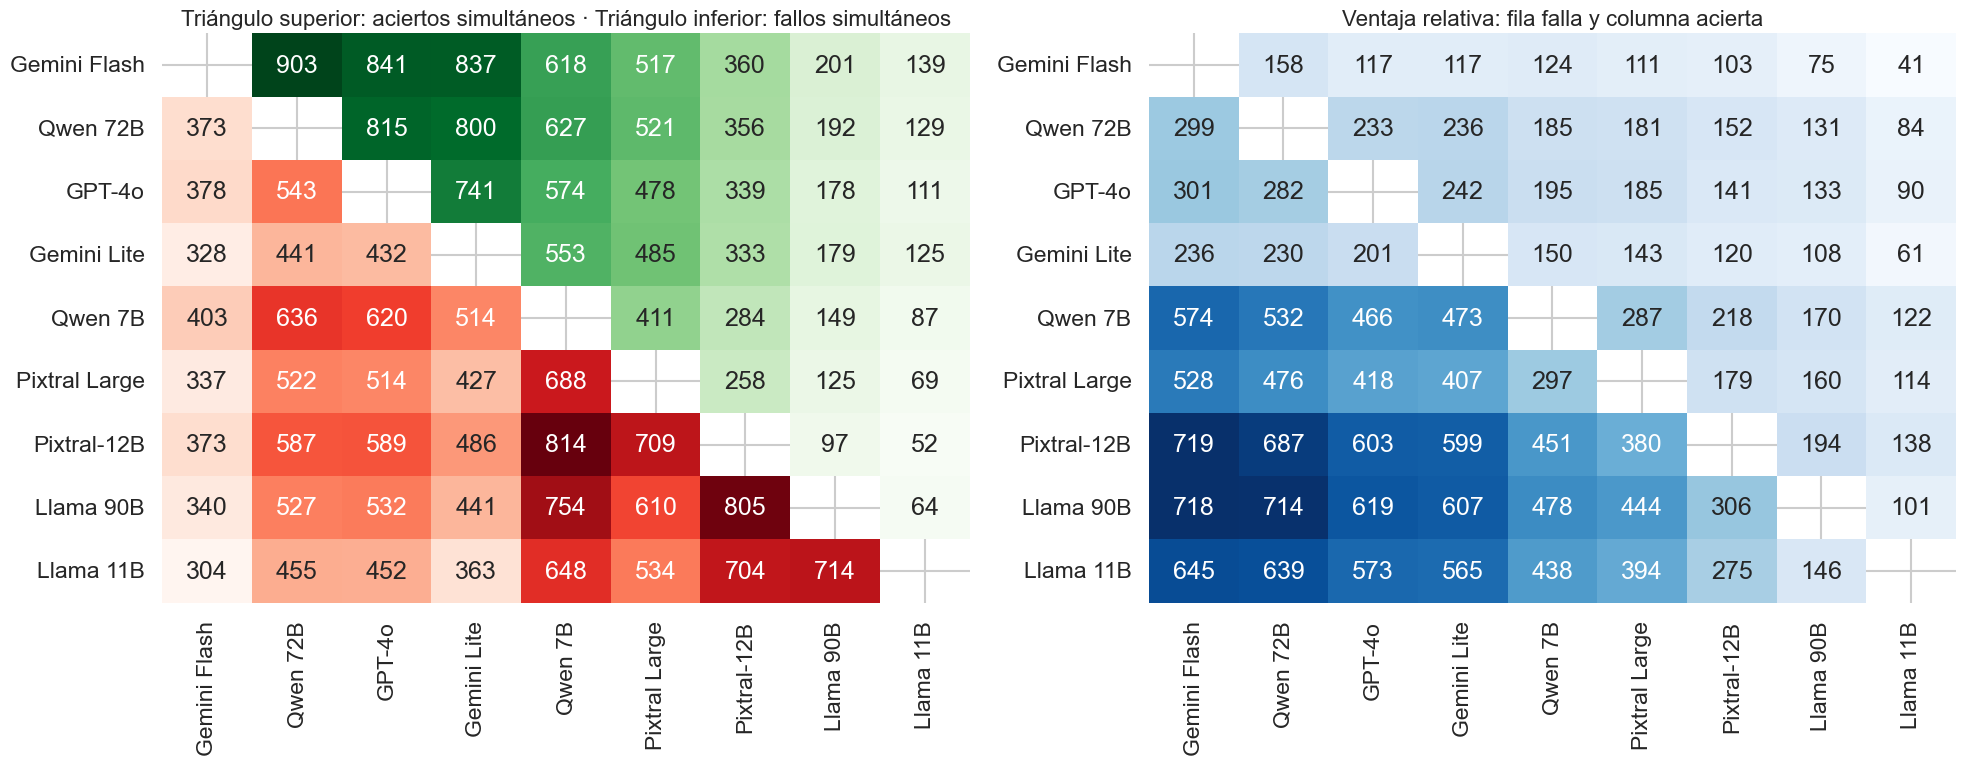

In [12]:
both_correct, both_wrong, row_fail_col_succeed = pairwise_matrices(df)

correct_matrix = both_correct.copy()
wrong_matrix = both_wrong.copy()
advantage_matrix = row_fail_col_succeed.copy()

correct_matrix.index = correct_matrix.columns = [MODEL_SHORT[m] for m in MODEL_ORDER]
wrong_matrix.index = wrong_matrix.columns = [MODEL_SHORT[m] for m in MODEL_ORDER]
advantage_matrix.index = advantage_matrix.columns = [MODEL_SHORT[m] for m in MODEL_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

upper_mask = np.tril(np.ones_like(correct_matrix, dtype=bool))
lower_mask = np.triu(np.ones_like(wrong_matrix, dtype=bool))

sns.heatmap(correct_matrix, mask=upper_mask, cmap="Greens", annot=True, fmt=".0f", ax=axes[0], cbar=False)
sns.heatmap(wrong_matrix, mask=lower_mask, cmap="Reds", annot=True, fmt=".0f", ax=axes[0], cbar=False)
axes[0].set_title("Triángulo superior: aciertos simultáneos · Triángulo inferior: fallos simultáneos")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

advantage_matrix = advantage_matrix.mask(np.eye(len(advantage_matrix), dtype=bool))
sns.heatmap(advantage_matrix, cmap="Blues", annot=True, fmt=".0f", ax=axes[1], cbar=False)
axes[1].set_title("Ventaja relativa: fila falla y columna acierta")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Comentario

Esta matriz de coocurrencia muestra una pauta clara:
los modelos fuertes aciertan muchas veces a la vez, pero también comparten muchos errores.

Eso significa que sí existe complementariedad, pero es limitada. No estamos ante modelos que cubran
huecos totalmente distintos, sino ante sistemas que suelen converger tanto en el éxito como en el fracaso.
Por eso los ensembles ayudan, pero no eliminan los casos realmente duros.

**Explicación celda**

Compara precisión global, precisión condicionada a responder y tasa de abstención de cada modelo.
También dibuja un dispersograma para ver si la abstención parece estar bien calibrada o no.

,Modelo,Precisión global,Precisión cuando responde,Tasa No Answer
0,GPT-4o,52.45,55.98,6.30
1,Gemini Flash,60.10,69.32,13.30
2,Gemini Lite,51.80,60.69,14.65
3,Llama 11B,10.65,16.30,34.65
4,Llama 90B,16.15,20.65,21.80
5,Pixtral Large,35.15,41.33,14.95
6,Pixtral-12B,25.45,28.55,10.85
7,Qwen 72B,58.40,58.43,0.05
8,Qwen 7B,40.60,41.01,1.00


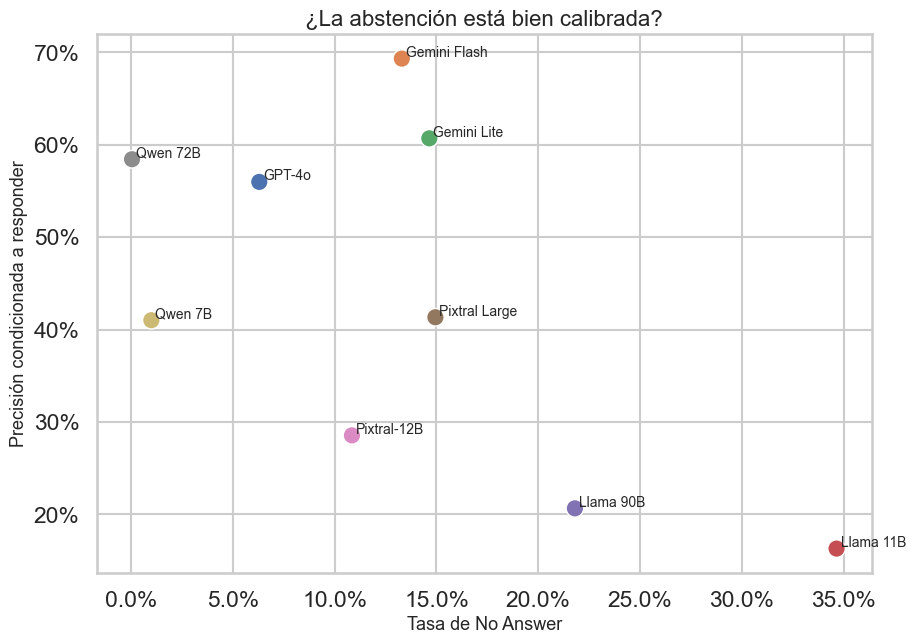

In [13]:
answer_quality = (
    long_df.groupby("model")
    .agg(
        accuracy=("is_correct", "mean"),
        no_answer_rate=("is_no_answer", "mean"),
    )
    .assign(
        answered_accuracy=lambda x: (
            long_df.loc[~long_df["is_no_answer"]]
            .groupby("model")["is_correct"]
            .mean()
            .reindex(x.index)
            .to_numpy()
        )
    )
    .reset_index()
)
answer_quality["model_short"] = answer_quality["model"].map(MODEL_SHORT)

display((answer_quality.loc[:, ["model_short", "accuracy", "answered_accuracy", "no_answer_rate"]]
         .rename(columns={"model_short": "Modelo", "accuracy": "Precisión global", "answered_accuracy": "Precisión cuando responde", "no_answer_rate": "Tasa No Answer"})
         .assign(**{
             "Precisión global": lambda x: (x["Precisión global"] * 100).round(2),
             "Precisión cuando responde": lambda x: (x["Precisión cuando responde"] * 100).round(2),
             "Tasa No Answer": lambda x: (x["Tasa No Answer"] * 100).round(2),
         })))

plt.figure(figsize=(10, 7))
sns.scatterplot(data=answer_quality, x="no_answer_rate", y="answered_accuracy", hue="model_short", s=160)
for _, row in answer_quality.iterrows():
    plt.text(row["no_answer_rate"] + 0.002, row["answered_accuracy"] + 0.002, row["model_short"], fontsize=10)
plt.xlabel("Tasa de No Answer")
plt.ylabel("Precisión condicionada a responder")
plt.title("¿La abstención está bien calibrada?")
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend([], [], frameon=False)
plt.show()

### Comentario

La abstención no significa lo mismo para todos los modelos. El que más se abstiene es
**Llama 3.2 11B Vision Instruct** (34.6% de `No Answer`) y, aun así,
su precisión cuando sí responde sigue siendo baja. En cambio, el mejor valor de precisión condicionada a responder
es **Gemini 2.0 Flash** con **69.3%**.

La interpretación práctica es que Gemini usa la abstención de forma relativamente selectiva,
pero Llama no. `Qwen-VL 72B` es especialmente interesante porque casi nunca se abstiene y aun así conserva
una precisión alta: en esta base, su política de respuesta es mucho más agresiva pero no se degrada demasiado.

**Explicación celda**

Busca los peores subgrupos operativos de cada modelo combinando modalidad, idioma y nivel.
Se queda con los slices con suficiente tamaño muestral para evitar conclusiones basadas en casos residuales.

In [14]:
weak_slices = (
    long_df.groupby(["model", "Imagen", "idioma", "Nivel"])
    .agg(n=("is_correct", "size"), acc=("is_correct", "mean"))
    .reset_index()
)
weak_slices = weak_slices.loc[weak_slices["n"] >= 20].copy()
weak_slices["model_short"] = weak_slices["model"].map(MODEL_SHORT)
weak_slices = (
    weak_slices.sort_values(["model", "acc", "n"], ascending=[True, True, False])
    .groupby("model")
    .head(3)
    .loc[:, ["model_short", "Imagen", "idioma", "Nivel", "n", "acc"]]
    .rename(
        columns={
            "model_short": "Modelo",
            "Imagen": "Necesita imagen",
            "idioma": "Idioma",
            "Nivel": "Nivel",
            "n": "n",
            "acc": "Precisión",
        }
    )
)
weak_slices["Precisión"] = (weak_slices["Precisión"] * 100).round(2)
display(weak_slices)

,Modelo,Necesita imagen,Idioma,Nivel,n,Precisión
30,GPT-4o,SI,frances,2,43,16.28
33,GPT-4o,SI,frances,5,29,17.24
31,GPT-4o,SI,frances,3,27,22.22
81,Gemini Flash,SI,ingles,2,27,25.93
70,Gemini Flash,SI,castellano,2,21,28.57
76,Gemini Flash,SI,frances,2,43,32.56
137,Gemini Lite,SI,valenciano,6,58,20.69
130,Gemini Lite,SI,ingles,5,20,25.00
122,Gemini Lite,SI,frances,2,43,25.58
139,Llama 11B,NO,castellano,2,37,0.00


### Comentario

Esta tabla es útil porque baja del promedio global al “peor entorno operativo” de cada modelo.
Los peores slices se concentran de forma muy clara en preguntas **con imagen** y, con bastante frecuencia,
en niveles bajos e intermedios donde la figura pesa más en la resolución.

En otras palabras: muchos fallos no vienen de la parte algebraica dura, sino de no interpretar bien la escena visual
cuando la pregunta obliga a leer piezas, desplegables, intersecciones o configuraciones espaciales.

**Explicación celda**

Pasa del análisis por modelo al análisis por pregunta.
Cuenta cuántos modelos aciertan cada ítem, cuántos se abstienen y resume la distribución de dureza del benchmark.

,num_correct,num_no_answer
count,2000.00,2000.00
mean,3.51,1.18
std,2.18,1.03
min,0.00,0.00
25%,2.00,0.00
50%,3.00,1.00
75%,5.00,2.00
max,9.00,6.00


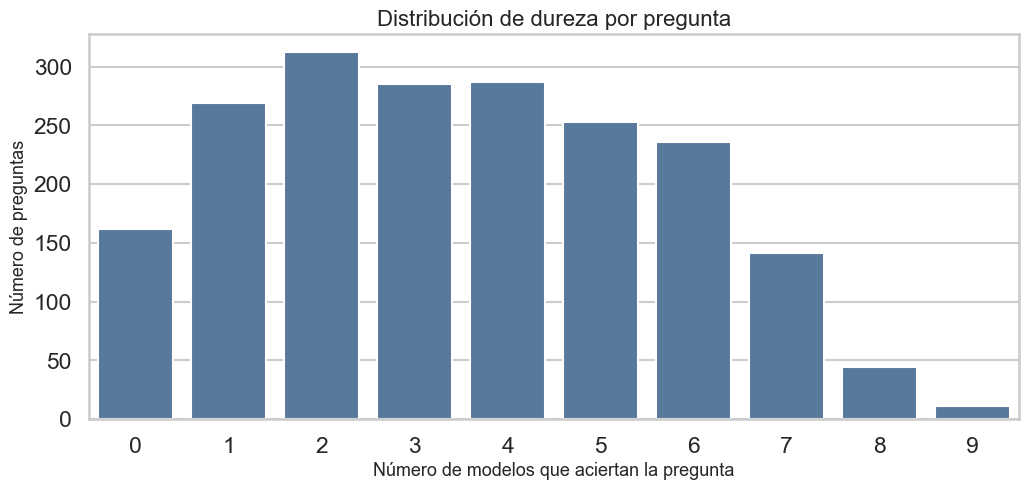

,Métrica,Valor
0,Preguntas que ningún modelo acierta,8.10
1,Preguntas que todos responden mal (sin No Answer),1.50
2,No Answer medio en preguntas all-fail,1.54


In [15]:
wide_correct = pd.DataFrame(
    {model: df[f"response {model}"].astype(str).str.strip().eq(df["ground truth"]) for model in MODEL_ORDER}
)
wide_no_answer = pd.DataFrame(
    {model: df[f"response {model}"].astype(str).str.strip().eq("No Answer") for model in MODEL_ORDER}
)

item_metrics = df[["Referencia", "idioma", "Imagen", "Tematica", "Nivel", "ground truth", "Enunciado"]].copy()
item_metrics["num_correct"] = wide_correct.sum(axis=1)
item_metrics["num_no_answer"] = wide_no_answer.sum(axis=1)
item_metrics["all_fail"] = item_metrics["num_correct"].eq(0)
item_metrics["all_answer_wrong"] = item_metrics["all_fail"] & item_metrics["num_no_answer"].eq(0)

display(item_metrics.loc[:, ["num_correct", "num_no_answer"]].describe().round(2))

plt.figure(figsize=(12, 5))
sns.countplot(x="num_correct", data=item_metrics, color="#4c78a8")
plt.title("Distribución de dureza por pregunta")
plt.xlabel("Número de modelos que aciertan la pregunta")
plt.ylabel("Número de preguntas")
plt.show()

hardness_summary = pd.DataFrame(
    [
        {"Métrica": "Preguntas que ningún modelo acierta", "Valor": item_metrics["all_fail"].mean() * 100},
        {"Métrica": "Preguntas que todos responden mal (sin No Answer)", "Valor": item_metrics["all_answer_wrong"].mean() * 100},
        {"Métrica": "No Answer medio en preguntas all-fail", "Valor": item_metrics.loc[item_metrics["all_fail"], "num_no_answer"].mean()},
    ]
)
display(hardness_summary.round(2))

### Comentario

La distribución de dureza deja un dato muy fuerte: **8.1%** de las preguntas
no las acierta ningún modelo. Sin embargo, solo **1.5%** son casos
en los que todos responden mal sin abstenerse.

Eso quiere decir que los fallos conjuntos suelen mezclar dos fenómenos: varios errores explícitos y, además,
alguna abstención. En promedio, cuando una pregunta derrota a todos los modelos, aparecen
**1.54** abstenciones por problema.

**Explicación celda**

Calcula tablas de *lift* para ver qué tipos de preguntas están sobrerrepresentados entre los casos que nadie acierta.
Además, lista algunos de los ítems más duros para facilitar una futura inspección cualitativa.

In [16]:
def build_lift_table(column: str) -> pd.DataFrame:
    base = item_metrics[column].fillna("Sin apoyo visual").value_counts(normalize=True)
    hard = item_metrics.loc[item_metrics["all_fail"], column].fillna("Sin apoyo visual").value_counts(normalize=True)
    out = (
        pd.DataFrame({"base_%": base * 100, "all_fail_%": hard * 100})
        .fillna(0)
        .assign(lift=lambda x: np.where(x["base_%"] > 0, x["all_fail_%"] / x["base_%"], np.nan))
        .sort_values("lift", ascending=False)
    )
    return out.round(2)

lift_image = build_lift_table("Imagen")
lift_theme = build_lift_table("Tematica")

display(lift_image)
display(lift_theme)

hardest_items = (
    item_metrics.sort_values(["num_correct", "num_no_answer", "Nivel"], ascending=[True, False, False])
    .loc[:, ["Referencia", "idioma", "Imagen", "Tematica", "Nivel", "ground truth", "num_correct", "num_no_answer", "Enunciado"]]
    .head(12)
)
display(hardest_items)

,base_%,all_fail_%,lift
Imagen,,,
SI,42.95,69.75,1.62
NO,57.05,30.25,0.53


,base_%,all_fail_%,lift
Tematica,,,
Álgebra y Aritmética Visual,8.25,17.28,2.10
Lógica y Razonamiento Visual,6.20,12.96,2.09
Combinatoria y Probabilidad,4.65,8.64,1.86
Patrones y Secuencias,5.05,8.64,1.71
Geometría y Figuras,18.80,22.22,1.18
Sin apoyo visual,57.05,30.25,0.53


,Referencia,idioma,Imagen,Tematica,Nivel,ground truth,num_correct,num_no_answer,Enunciado
188,2020_nivel5_30,castellano,NO,NaN,5,D,0,5,Ocho enteros positivos consecutivos de tres cifras tienen la siguiente propiedad: cada uno de ellos es divisible por la cifra de las uni...
729,2018_Benjamin_24,ingles,SI,Geometría y Figuras,2,D,0,5,The figure shown consists of one square part and eight rectangular parts. Each part is 8 cm wide. Peter assembles all parts to form one ...
1647,2019_nivell6_23,valenciano,SI,Álgebra y Aritmética Visual,6,C,0,4,"Els vèrtexs de la xarxa que es mostra a la figura estan marcats amb els nombres de l’1 al 10, a cadascun dels deu vèrtexs un nombre dife..."
695,2014_Etudiants_6,frances,NO,NaN,5,C,0,4,"Une année ayant tous ses chiffres différents et son dernier chiffre strictement plus grand que la somme des autres, comme 2014, est appe..."
1623,2019_nivell5_27,valenciano,NO,NaN,5,D,0,4,"Quants nombres enters del conjunt {1000, 1001, 1002, 1003, ..., 1998, 1999} tenen la propietat que, si en suprimim una xifra qualsevol, ..."
1950,2024_nivell5_16,valenciano,SI,Álgebra y Aritmética Visual,5,B,0,4,Escrivim un nombre en cadascun dels dotze cercles mostrats en la figura. El nombre dins de cada quadrat indica el producte dels nombres ...
269,2017_nivel4_23,castellano,NO,NaN,4,C,0,4,"Las diagonales de un cuadrilátero lo dividen en 4 triángulos, de áreas a, b, c, d, que son números primos que verifican \(a \cdot b = c ..."
734,2018_Kadett_11,ingles,SI,Álgebra y Aritmética Visual,3,B,0,4,"Martina multiplies two, two-digit numbers and then paints over some of the digits. How big is the sum of the three digits that Martina h..."
1568,2019_nivell3_4,valenciano,SI,Patrones y Secuencias,3,D,0,4,Tres anelles estan enllaçades tal com es veu a la imatge de la dreta. Quin dels diagrames següents mostra també tres anelles enllaçades ...
17,2024_nivel2_6,castellano,NO,NaN,2,B,0,4,"Sin levantar el lápiz, María quiere dibujar la figura que se muestra (aunque deba pasar varias veces por el mismo segmento). ¿Cuál es la..."


### Comentario

Las preguntas que derrotan a todos los modelos están muy sobrerrepresentadas en el bloque visual.
Frente a su peso base en el dataset, las preguntas **con imagen** tienen un *lift* de
**1.62** en el conjunto `all-fail`.

Por temática, los lifts más altos aparecen en:

- **Álgebra y Aritmética Visual** (*lift* 2.10),
- **Lógica y Razonamiento Visual** (*lift* 2.09),
- **Combinatoria y Probabilidad** (*lift* 1.86).

Es decir, los fallos conjuntos no se reparten al azar: se concentran sobre todo en álgebra visual,
lógica visual y combinatoria/probabilidad con soporte gráfico.

**Explicación celda**

Analiza errores compartidos de forma más estricta.
Mide cuándo muchos modelos convergen en la misma opción equivocada y cuándo los tres modelos más fuertes coinciden exactamente.

In [17]:
responses = pd.DataFrame({model: df[f"response {model}"].astype(str).str.strip() for model in MODEL_ORDER})
option_counts = pd.DataFrame({opt: responses.eq(opt).sum(axis=1) for opt in "ABCDE"})

wrong_counts = option_counts.copy()
for opt in "ABCDE":
    wrong_counts.loc[df["ground truth"].eq(opt), opt] = -1

item_metrics["max_wrong_consensus"] = wrong_counts.max(axis=1)
item_metrics["majority_wrong_5plus"] = item_metrics["max_wrong_consensus"].ge(5)

top3 = ["Gemini 2.0 Flash", "Qwen-VL 72B", "GPT-4o"]
top3_responses = pd.DataFrame({model: responses[model] for model in top3})
item_metrics["top3_all_same"] = (~top3_responses.eq("No Answer").any(axis=1)) & top3_responses.nunique(axis=1).eq(1)
item_metrics["top3_consensus_correct"] = item_metrics["top3_all_same"] & top3_responses.iloc[:, 0].eq(df["ground truth"])

consensus_summary = pd.DataFrame(
    [
        {"Métrica": "Preguntas con una opción errónea compartida por >=5 modelos", "Valor": item_metrics["majority_wrong_5plus"].mean() * 100},
        {"Métrica": "Tasa anterior en preguntas con imagen", "Valor": item_metrics.loc[item_metrics["Imagen"].eq("SI"), "majority_wrong_5plus"].mean() * 100},
        {"Métrica": "Tasa anterior en preguntas sin imagen", "Valor": item_metrics.loc[item_metrics["Imagen"].eq("NO"), "majority_wrong_5plus"].mean() * 100},
        {"Métrica": "Casos donde top-3 coinciden exactamente", "Valor": item_metrics["top3_all_same"].mean() * 100},
        {"Métrica": "Precisión del top-3 cuando coincide", "Valor": item_metrics.loc[item_metrics["top3_all_same"], "top3_consensus_correct"].mean() * 100},
    ]
)
display(consensus_summary.round(2))

,Métrica,Valor
0,Preguntas con una opción errónea compartida por >=5 modelos,6.65
1,Tasa anterior en preguntas con imagen,9.43
2,Tasa anterior en preguntas sin imagen,4.56
3,Casos donde top-3 coinciden exactamente,39.15
4,Precisión del top-3 cuando coincide,90.80


**Explicación celda**

Desglosa la composición visual del subconjunto en el que coincide exactamente el top-3.
La comparación con la distribución global sirve para ver si ese consenso aparece sobre el mismo tipo de preguntas
o si está sesgado hacia preguntas con menos carga visual.

In [18]:
top3_image_distribution = pd.DataFrame(
    [
        {
            "Grupo": "Coincidencia exacta top-3",
            "n": item_metrics["top3_all_same"].sum(),
            "% con imagen": item_metrics.loc[item_metrics["top3_all_same"], "Imagen"].eq("SI").mean() * 100,
            "% sin imagen": item_metrics.loc[item_metrics["top3_all_same"], "Imagen"].eq("NO").mean() * 100,
        },
        {
            "Grupo": "Dataset completo",
            "n": len(df),
            "% con imagen": df["Imagen"].eq("SI").mean() * 100,
            "% sin imagen": df["Imagen"].eq("NO").mean() * 100,
        },
    ]
)
display(top3_image_distribution.round(2))

,Grupo,n,% con imagen,% sin imagen
0,Coincidencia exacta top-3,783,22.61,77.39
1,Dataset completo,2000,42.95,57.05


### Comentario

Un patrón especialmente interesante es el **error compartido**. En el **6.7%**
de las preguntas aparece una opción incorrecta apoyada por al menos 5 modelos. Este fenómeno casi se duplica
en preguntas con imagen (**9.4%**) frente a las que no requieren imagen
(**4.6%**).

La tabla adicional ayuda a matizar el bloque de consenso del top-3. Cuando los tres modelos más fuertes coinciden exactamente,
eso ocurre en el **39.1%** de la base (**783** preguntas)
y su precisión en esos casos sube al **90.8%**.

Pero ese consenso no aparece sobre una muestra neutral del benchmark. Dentro de las preguntas donde coincide el top-3,
solo **22.6%** requieren imagen y **77.4%** no la requieren,
mientras que en el dataset completo esas proporciones son **43.0%** con imagen y
**57.0%** sin imagen. En otras palabras, el acuerdo del top-3 está sesgado hacia preguntas
menos dependientes de la figura, así que su alta fiabilidad debe interpretarse teniendo en cuenta esa composición.

**Explicación celda**

Compara tres ideas de agregación entre modelos: mejor sistema individual, mejor par en modo oráculo
y varios votos mayoritarios. Sirve para estimar cuánto margen real hay para combinar modelos.

In [19]:
ensemble_rows = []

best_single_acc = long_df.groupby("model")["is_correct"].mean().sort_values(ascending=False).iloc[0]
ensemble_rows.append({"Sistema": "Mejor modelo individual", "Precisión": best_single_acc * 100, "Detalle": MODEL_SHORT[MODEL_ORDER[0]]})

best_pair = None
best_pair_acc = -1
for combo in combinations(MODEL_ORDER, 2):
    acc = pd.concat(
        [df[f"response {model}"].astype(str).str.strip().eq(df["ground truth"]) for model in combo],
        axis=1,
    ).any(axis=1).mean()
    if acc > best_pair_acc:
        best_pair_acc = acc
        best_pair = combo
ensemble_rows.append({"Sistema": "Oráculo del mejor par", "Precisión": best_pair_acc * 100, "Detalle": " + ".join(MODEL_SHORT[m] for m in best_pair)})

for label, models in {
    "Voto mayoritario top-3": ["Gemini 2.0 Flash", "Qwen-VL 72B", "GPT-4o"],
    "Voto mayoritario top-5": ["Gemini 2.0 Flash", "Qwen-VL 72B", "GPT-4o", "Gemini 2.0 Flash Lite", "Qwen-VL 7B"],
    "Voto mayoritario 9 modelos": MODEL_ORDER,
}.items():
    pred = df.apply(lambda row: majority_vote(row, models), axis=1)
    ensemble_rows.append({"Sistema": label, "Precisión": pred.eq(df["ground truth"]).mean() * 100, "Detalle": " + ".join(MODEL_SHORT[m] for m in models)})

ensemble_table = pd.DataFrame(ensemble_rows).sort_values("Precisión", ascending=False)
display(ensemble_table.round(2))

,Sistema,Precisión,Detalle
1,Oráculo del mejor par,73.35,Gemini Flash + Qwen 72B
3,Voto mayoritario top-5,64.90,Gemini Flash + Qwen 72B + GPT-4o + Gemini Lite + Qwen 7B
2,Voto mayoritario top-3,64.75,Gemini Flash + Qwen 72B + GPT-4o
4,Voto mayoritario 9 modelos,62.65,Gemini Flash + Qwen 72B + GPT-4o + Gemini Lite + Qwen 7B + Pixtral Large + Pixtral-12B + Llama 90B + Llama 11B
0,Mejor modelo individual,60.10,Gemini Flash


### Comentario

El mejor oráculo de dos modelos mejora de forma clara al mejor sistema individual:
pasa de **60.1%** a **73.4%**.
Eso confirma que sí hay complementariedad.

Pero el voto mayoritario cuenta otra historia: el `top-3` solo sube hasta una franja intermedia.
Es decir, los mejores modelos no se corrigen tanto entre sí como para convertir el consenso en un salto masivo.
Esto cuadra perfectamente con la coocurrencia vista antes: comparten muchos aciertos, pero también muchos fallos.

**Explicación celda**

Estudia la distribución de respuestas emitidas por cada modelo y sus confusiones más frecuentes.
Esto permite detectar sesgos por opción y errores recurrentes de predicción.

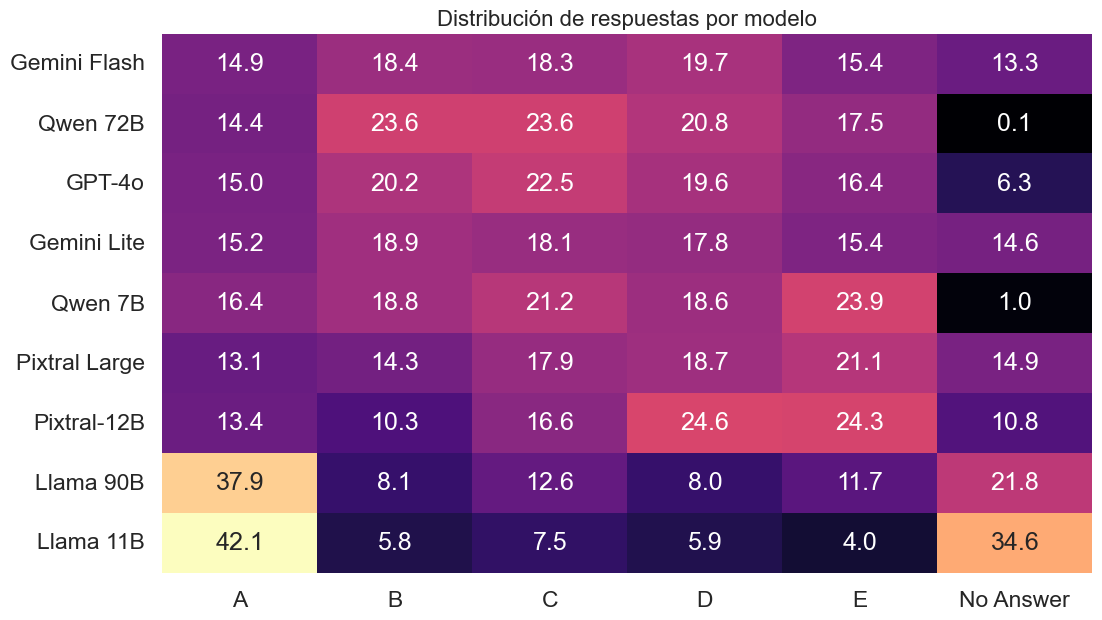

,Modelo,Ground truth,Predicción errónea,Frecuencia
0,Gemini Flash,A,No Answer,31
1,Gemini Flash,A,C,22
2,Gemini Flash,B,No Answer,65
3,Gemini Flash,B,A,38
4,Gemini Flash,C,No Answer,59
5,Gemini Flash,C,A,41
6,Gemini Flash,D,No Answer,66
7,Gemini Flash,D,C,43
8,Gemini Flash,E,No Answer,45
9,Gemini Flash,E,D,22


In [20]:
ground_truth_dist = df["ground truth"].value_counts(normalize=True).sort_index()
response_dist = (
    long_df.groupby(["model", "response"]).size().unstack(fill_value=0).reindex(index=MODEL_ORDER)
)
if "No Answer" not in response_dist.columns:
    response_dist["No Answer"] = 0
response_dist = response_dist[[*list("ABCDE"), "No Answer"]]
response_dist = response_dist.div(response_dist.sum(axis=1), axis=0)

plt.figure(figsize=(12, 7))
sns.heatmap(response_dist.rename(index=MODEL_SHORT) * 100, annot=True, fmt=".1f", cmap="magma", cbar=False)
plt.title("Distribución de respuestas por modelo")
plt.xlabel("")
plt.ylabel("")
plt.show()

confusion_rows = []
for model in MODEL_ORDER:
    cm = pd.crosstab(df["ground truth"], df[f"response {model}"].astype(str).str.strip())
    for gt in "ABCDE":
        row = cm.loc[gt].drop(labels=[gt], errors="ignore").sort_values(ascending=False)
        for predicted, count in row.head(2).items():
            confusion_rows.append(
                {
                    "Modelo": MODEL_SHORT[model],
                    "Ground truth": gt,
                    "Predicción errónea": predicted,
                    "Frecuencia": int(count),
                }
            )

confusion_table = pd.DataFrame(confusion_rows)
display(confusion_table.head(18))

### Comentario

Este bloque deja ver sesgos muy marcados. El caso extremo es `Llama 11B`, que responde
**A** en el **42.1%** de toda la base. En el otro extremo,
`Qwen 72B` apenas usa `No Answer` (**0.05%**).

Los sesgos por opción ayudan a explicar parte del rendimiento. Cuando un modelo reparte respuestas
de forma muy desbalanceada, no solo baja la precisión global: también aparecen confusiones recurrentes
que no parecen ligadas al contenido del problema, sino a una política de decodificación o a una heurística interna.

## Conclusiones

1. La caída entre preguntas con imagen y sin imagen es real y grande para los modelos fuertes.
2. `Gemini 2.0 Flash` y `Qwen-VL 72B` son los mejores sistemas del benchmark, pero con perfiles distintos: Gemini combina más razonamiento selectivo y más abstención; Qwen responde casi siempre.
3. La dificultad escolar no coincide exactamente con la dificultad visual: los niveles altos salen mejor en media porque contienen más preguntas sin imagen.
4. Los fallos conjuntos no son aleatorios. Se concentran en preguntas visuales, sobre todo en álgebra visual, lógica visual y combinatoria/probabilidad con soporte gráfico.
5. Hay complementariedad entre modelos, pero no suficiente para “resolver” el benchmark por consenso. El mejor par mejora bastante, pero incluso el oráculo de 9 modelos deja un bloque de preguntas sin resolver.
6. Cuando los tres mejores modelos coinciden, el consenso es muy fiable. Cuando discrepan, la incertidumbre real del problema sube mucho.
7. Algunos modelos muestran sesgos de salida muy fuertes por opción, especialmente las variantes Llama; estos sesgos son una pista importante para la fase cualitativa posterior.

En conjunto, la evidencia apunta a que el cuello de botella principal no es el cálculo simbólico puro, sino la integración entre percepción visual y razonamiento matemático estructurado.